In [64]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE1/'
mouse = 29
day = 23

# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

29 23
optimal travel lag is 7.357357357357358 cm based on kde of travel at max spatial information
optimal travel lag is 7.357357357357358 cm
there are 141 non_grid and non_spatial_cells
there are 19 grid_cells
there are 114 non grid spatial cells
there are 27 non spatial cells
there are 0 speed cells
there are 160 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
unique brain regions ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5' 'PAR']
there are 207 MEC cells
there are 4 PARA cells
there are 0 PRE cells
there are 0 VIS cells
there are 0 CERE cells
there are 0 other cells
there are 0 SUB cells
there are 211 all cells
params min_cluster_size and cluster_selection_epsilon are deprecated, these are now set to default values of 3 and 0.4 respectively
Not merging labels 0 and 1 with distance 39.09368458573167
Found 3 modules with HDBSCAN for mouse 29 day 23
for each module , the numb

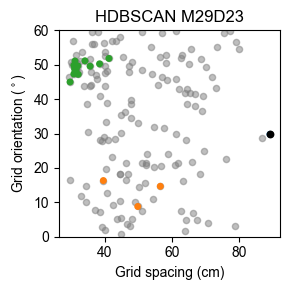

for module 0, there are 3 cells with average spacing 48.661737523324746
for module 1, there are 15 cells with average spacing 32.85775663419034
29 23
for module 1, there are 15 cells
for module 0, there are 3 cells
plotting vr rate maps using cluster_ids [132, 160, 184, 191, 194, 202, 213, 214, 216, 217, 219, 362, 389, 411, 416]
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147


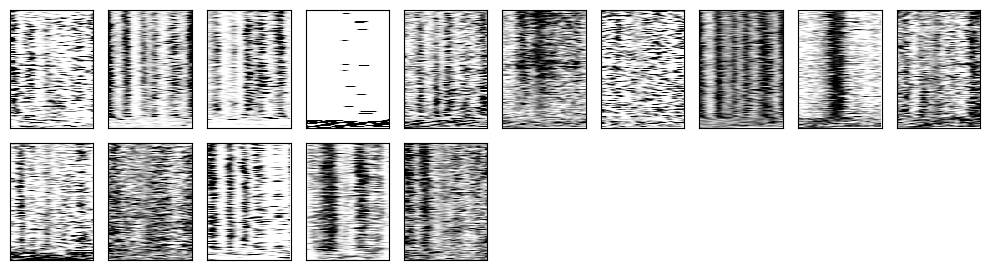

plotting vr rate maps using cluster_ids [332, 425, 430]
n trials: 147
n trials: 147
n trials: 147


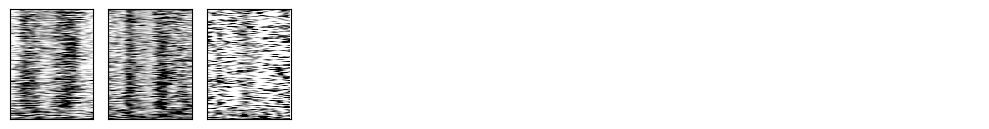

plotting vr rate maps using cluster_ids [24, 28, 53, 61, 65, 79, 81, 86, 89, 95, 104, 108, 144, 157, 163, 169, 186, 205, 210, 211, 221, 226, 231, 239, 241, 247, 249, 251, 255, 256, 259, 266, 267, 269, 270, 278, 292, 293, 296, 297, 301, 311, 312, 315, 318, 321, 323, 327, 329, 334, 340, 341, 342, 345, 346, 349, 350, 352, 353, 354, 356, 363, 366, 369, 370, 371, 373, 374, 375, 376, 377, 378, 380, 382, 383, 385, 387, 391, 392, 393, 394, 396, 397, 398, 399, 400, 403, 404, 405, 409, 412, 414, 418, 419, 420, 422, 426, 427, 429, 433, 434, 440, 446, 450, 451, 452, 457, 461, 462, 464, 466, 467, 469, 472]
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trial

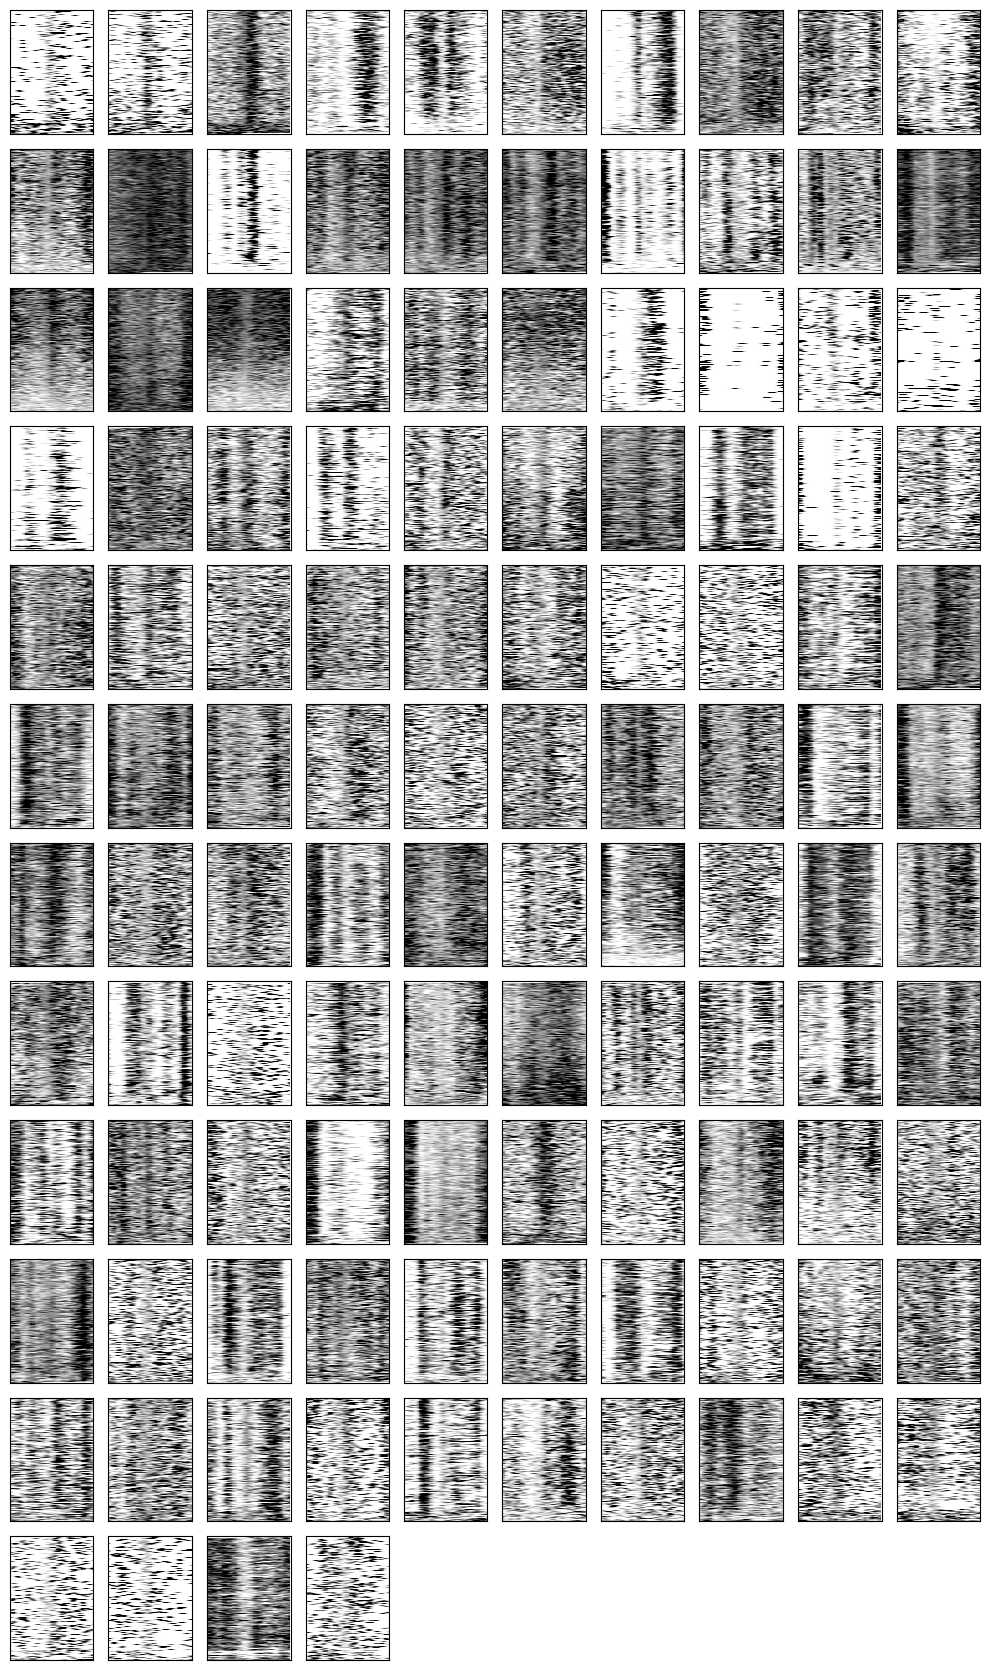

plotting vr rate maps using cluster_ids [20, 26, 29, 30, 32, 33, 34, 133, 198, 244, 268, 272, 275, 317, 335, 336, 359, 364, 368, 388, 408, 444, 447, 454, 458, 459, 463]
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147


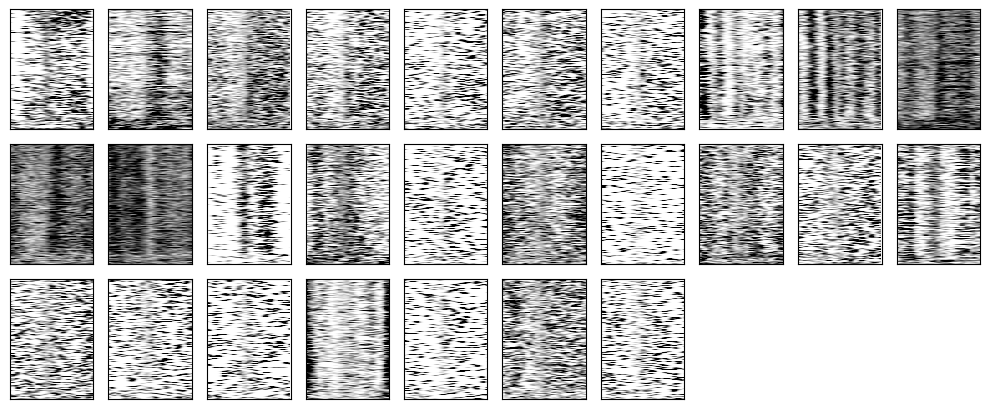

plotting vr rate maps using cluster_ids [132, 160, 184, 191, 194, 202, 213, 214, 216, 217, 219, 332, 343, 362, 389, 411, 416, 425, 430]
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147


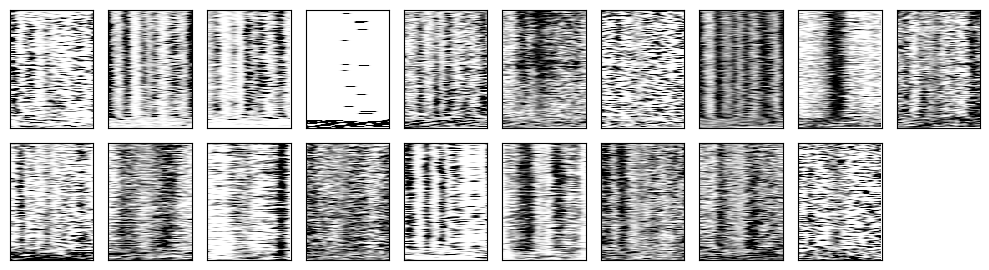

plotting vr rate maps using cluster_ids []
plotting vr rate maps using cluster_ids [332 343 425 430]
n trials: 147
n trials: 147
n trials: 147
n trials: 147


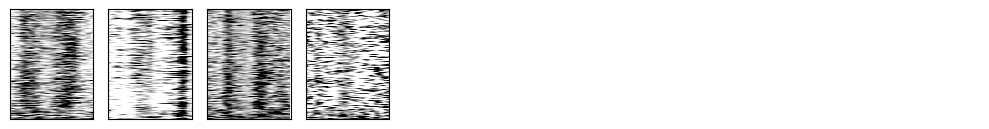

In [3]:
gcs, ngs, ns, sc, ngs_ns, all = cell_classification_of1(mouse, day, percentile_threshold=95) # subset
rc, rsc, vr_ns = cell_classification_vr(mouse, day)
mec, para, pre, sub, vis, cere, other, all_by_anatomy = cell_classification_anatomy(mouse, day)
g_m_ids, g_m_cluster_ids = HDBSCAN_grid_modules(gcs, all, mouse, day, min_cluster_size=3, cluster_selection_epsilon=3, 
                                                figpath=fig_path, curate_with_vr=False, curate_with_brain_region=True, plot_curate=False) # create grid modules using HDBSCAN    

plot_grid_modules_rate_maps(gcs, g_m_ids, g_m_cluster_ids, mouse, day, figpath=fig_path)

# we now have cluster ids classified into modules, non grid spatial cells and non spatial cells 
# as defined by activity in the open field
g_m_cluster_ids = sorted(g_m_cluster_ids, key=len, reverse=True) 
cluster_ids_by_group = []
cluster_ids_by_group.extend(g_m_cluster_ids) # grid cells by module [0,1,2...]
cluster_ids_by_group.append(ngs.cluster_id.values.tolist()) # non grid spatial [-4]
cluster_ids_by_group.append(ns.cluster_id.values.tolist()) # non spatial cells [-3]
cluster_ids_by_group.append(gcs.cluster_id.values.tolist()) # all grid cells [-2]
cluster_ids_by_group.append(sc.cluster_id.values.tolist()) # speed cells [-1]

for m, cluster_ids in enumerate(cluster_ids_by_group):
    plot_vr_rate_maps(mouse, day, cluster_ids, label=f'{m}', figpath=fig_path)

plot_vr_rate_maps(mouse, day, np.setdiff1d(gcs.cluster_id.values, g_m_cluster_ids[0]), label=f'nocomodular_grid_cells', figpath=fig_path)

In [4]:
Mouse = f'M{mouse}'
data_paths = [f"/Users/harryclark/Documents/brainrender/probe_data/{Mouse}_probe_locations_{a}.mat" for a in [1,2,3,4]]
shank_offsets_SC = pd.read_csv('/Users/harryclark/Documents/brainrender/probe_data/shank_offsets.csv')
clusters_df = pd.read_csv(f'/Users/harryclark/Documents/brainrender/probe_data/extremum_channel_locations_kilosort4_0.csv')
clusters_df = clusters_df[clusters_df['mouse'] == mouse]
shank_offsets_SC = shank_offsets_SC[shank_offsets_SC['mouse'] == mouse]
clusters_df = reconstruct_shank_id(clusters_df, mouse)
probes_locs = [read_probe_mat(data_path) for data_path in data_paths]
adjusted_probes_locs_CCF = np.array([adjust_probe_locs(probe_locs) for probe_locs in probes_locs])
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = correct_for_left_side(adjusted_probes_locs_CCF)
adjusted_probe_locs_SC, adjusted_probe_locs_CCF = adjust_to_shank_offsets(adjusted_probe_locs_SC, shank_offsets_SC)

ymin = -300; ymax = 3000
xmin = -200; xmax = 1000
xs = np.arange(xmin, xmax, 1)
ys = np.arange(ymin, ymax, 1)

annotations = np.zeros((len(ys), len(xs)), dtype=object)
for yi, y in enumerate(ys):
    for xi, x in enumerate(xs):
        coord_SC, coord_CCF  = brain_coord_from_xy(x, y, adjusted_probe_locs_SC, shank_id=0)
        # use the CCF coordinates, get an index and look up the annotation in the brainrender allen_brain_10um volume
        z_CCF, y_CCF, x_CCF = np.round(coord_CCF/10).astype(int)
        annotation_index = annotations_set[z_CCF,y_CCF,x_CCF]
        if len(structure_set[structure_set['id'] == annotation_index]) ==1:
            annotation = structure_set[structure_set['id'] == annotation_index]['acronym'].iloc[0]
        else:
            annotation ='root' # out of brain
        annotations[yi,xi] = annotation

In [5]:
annotation_colors = get_annotation_colors_2D(annotations)

hi
29 16
optimal travel lag is 6.256256256256258 cm based on kde of travel at max spatial information
optimal travel lag is 6.256256256256258 cm
there are 46 non_grid and non_spatial_cells
there are 4 grid_cells
there are 34 non grid spatial cells
there are 12 non spatial cells
there are 0 speed cells
there are 50 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3']
for the grid cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3']
29 17
optimal travel lag is 10.060060060060067 cm based on kde of travel at max spatial information
optimal travel lag is 10.060060060060067 cm
there are 138 non_grid and non_spatial_cells
there are 6 grid_cells
there are 74 non grid spatial cells
there are 64 non spatial cells
there are 0 speed cells
there are 144 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
29 18
optimal travel lag is 13.063063063063

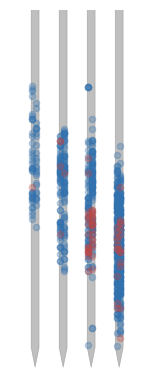

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
gcs_tmp_all = pd.DataFrame()
ngs_tmp_all = pd.DataFrame()
for day_tmp in [16,17,18,19,20,21,22,23,25]:
    gcs_tmp, ngs_tmp, _, _, _, _ = cell_classification_of1(mouse, day_tmp, percentile_threshold=95) # subset
    gcs_tmp_all = pd.concat([gcs_tmp_all, gcs_tmp])
    ngs_tmp_all = pd.concat([ngs_tmp_all, ngs_tmp])
ax.scatter(ngs_tmp_all.probe_x.values, ngs_tmp_all.probe_y.values, marker='o', color="#3171ae", alpha=0.3, s=20)
ax.scatter(gcs_tmp_all.probe_x.values, gcs_tmp_all.probe_y.values, marker='o', color="#c04744", alpha=0.3, s=20)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}_probe.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

hi


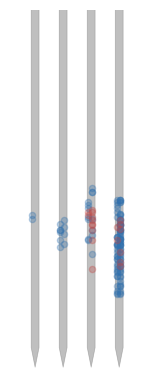

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
# plot cell locations 
ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="#3171ae", alpha=0.3, s=20)
ax.scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="#c04744", alpha=0.3, s=20)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

hi


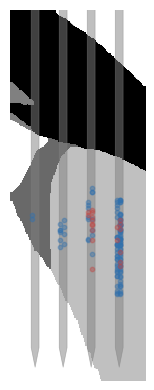

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
unique_colors = np.unique(annotation_colors)
for color in unique_colors:
    border_points = extract_border(annotation_colors, color, only_border=False)
    x_points = xs[border_points[:, 1]]
    y_points = ys[border_points[:, 0]]
    ax.scatter(x_points, y_points, color=color, s=1, label=color, rasterized=True)
plot_NP2_probe(ax, sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_saM29D23', 
               probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
# plot cell locations 
ax.scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="#3171ae", alpha=0.4, s=10)
ax.scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="#c04744", alpha=0.4, s=10)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_probe_brainrender.pdf', bbox_inches='tight', dpi=500) # use tight layout to avoid cutting off labels
plt.show()

In [7]:
tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False)
tcs_of, tcs_time_of, beh_of, clusters_of, ep_OF = compute_of_tcs(mouse,day, apply_zscore=False, apply_guassian_filter=False, optimal_shift=gcs.travel[0])
last_ephys_time_bin = clusters[clusters.index[0]].count(bin_size=time_bs, time_units = 'ms').index[-1]

# time binned variables for later
ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units = 's')
speed_in_time = np.array(beh['S'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep))
dt_in_time = np.array(beh['travel'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep)-((beh['trial_number'][0]-1)*tl))
pos_in_time = dt_in_time%tl
trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

x_pos_in_time_OF = np.array(beh_of['head_x'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))
y_pos_in_time_OF = np.array(beh_of['head_y'].bin_average(bin_size=time_bs, time_units = 'ms', ep=ep_OF))

if np.any(np.isnan(pos_in_time)):
    series = pd.Series(dt_in_time)
    filled_series = series.ffill().bfill()
    dt_in_time = np.array(filled_series)
    pos_in_time = dt_in_time%tl
    trial_number_in_time = (dt_in_time//tl)+beh['trial_number'][0]

if np.any(np.isnan(speed_in_time)):
    series = pd.Series(speed_in_time)
    filled_series = series.ffill().bfill()
    speed_in_time = np.array(speed_in_time)

if np.any(np.isnan(x_pos_in_time_OF)):
    series = pd.Series(x_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    x_pos_in_time_OF = np.array(filled_series)

if np.any(np.isnan(y_pos_in_time_OF)):
    series = pd.Series(y_pos_in_time_OF)
    filled_series = series.ffill().bfill()
    y_pos_in_time_OF = np.array(filled_series)

In [8]:
figpath_rm = '/Users/harryclark/Desktop/temp/'

In [9]:
plot_individual_rate_maps_with_avg_by_trial_type_with_open_field(mouse, day, df=gcs, label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_by_trial_type_with_open_field(mouse, day, df=ngs, label='NGS', figpath=figpath_rm)

n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n tria

In [10]:
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=gcs.cluster_id.values, label='GC', figpath=figpath_rm)
plot_individual_rate_maps_with_avg_by_trial_type(mouse, day, cluster_ids=ngs.cluster_id.values, label='NGS', figpath=figpath_rm)

n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n tria

In [11]:
plot_individual_of_rate_maps_optimal_versus_standard(mouse, day, df=gcs, label='GC', figpath=figpath_rm) 
plot_individual_of_rate_maps_optimal_versus_standard(mouse, day, df=ngs, label='NGS', figpath=figpath_rm)

In [12]:
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = True, spike_history=False, # We can choose!
                         window = time_bs, #this dataset has 100ms time bins
                         n_filters = 5,
                         max_time = 1000)

In [13]:
test_grid_cell_id = 214  # the grid cell we will use to test the model
predictor_grid_cell_id_1 = 194
predictor_grid_cell_id_2 = 389
predictor_non_grid_cell_id_3 = 65
predictor_non_grid_cell_id_4 = 198

In [14]:
pr2_results = []
for id in all_by_anatomy.cluster_id.values:
    y = np.array(tcs_time[test_grid_cell_id])  # target variable is the test grid cell
    X_id = np.stack([np.array(tcs_time[id])]).T
    Y_hat_id, pR2_cv_id = xgb_history.fit_cv(X_id, y, verbose=0, continuous_folds=True)
    mean_pr2 = np.nanmean(pR2_cv_id)
    pr2_results.append((id, mean_pr2))

# Sort by PR2, largest first
pr2_results_sorted = sorted(pr2_results, key=lambda x: x[1], reverse=True)

print("IDs ranked by mean pR2 (largest first):")
for id, pr2 in pr2_results_sorted:
    print(f"Cell ID: {id}, mean pR2: {pr2:.2f}")

IDs ranked by mean pR2 (largest first):
Cell ID: 214, mean pR2: 1.00
Cell ID: 160, mean pR2: 0.04
Cell ID: 184, mean pR2: 0.03
Cell ID: 198, mean pR2: 0.02
Cell ID: 389, mean pR2: 0.02
Cell ID: 186, mean pR2: 0.02
Cell ID: 194, mean pR2: 0.02
Cell ID: 272, mean pR2: 0.02
Cell ID: 211, mean pR2: 0.02
Cell ID: 220, mean pR2: 0.02
Cell ID: 61, mean pR2: 0.02
Cell ID: 108, mean pR2: 0.02
Cell ID: 411, mean pR2: 0.01
Cell ID: 86, mean pR2: 0.01
Cell ID: 144, mean pR2: 0.01
Cell ID: 163, mean pR2: 0.01
Cell ID: 101, mean pR2: 0.01
Cell ID: 210, mean pR2: 0.01
Cell ID: 89, mean pR2: 0.01
Cell ID: 268, mean pR2: 0.01
Cell ID: 226, mean pR2: 0.01
Cell ID: 65, mean pR2: 0.01
Cell ID: 387, mean pR2: 0.01
Cell ID: 394, mean pR2: 0.01
Cell ID: 367, mean pR2: 0.01
Cell ID: 133, mean pR2: 0.01
Cell ID: 334, mean pR2: 0.01
Cell ID: 319, mean pR2: 0.01
Cell ID: 231, mean pR2: 0.01
Cell ID: 369, mean pR2: 0.01
Cell ID: 290, mean pR2: 0.01
Cell ID: 434, mean pR2: 0.01
Cell ID: 419, mean pR2: 0.01
Cell ID

In [15]:
ngs_ids = set(ngs['cluster_id'])
gcs_ids = set(gcs[gcs.cluster_id != test_grid_cell_id]['cluster_id']) # all grid cells except the test cell

n = 10  # or any number you want
pr2_results_sorted = sorted(pr2_results, key=lambda x: x[1], reverse=True)
ngs_top_cluster_ids = [cid for cid, pr2 in pr2_results_sorted if cid in ngs_ids][:n]
ngs_top_cluster_ids2 = [cid for cid, pr2 in pr2_results_sorted if cid in ngs_ids][1:n]
gcs_top_cluster_ids = [cid for cid, pr2 in pr2_results_sorted if cid in gcs_ids][:n]
pr2_results_sorted = sorted(pr2_results, key=lambda x: x[1], reverse=False)
ngs_bottom_cluster_ids = [cid for cid, pr2 in pr2_results_sorted if cid in ngs_ids][:n]

cov_top_gcs = {cluster_id: tcs_time[cluster_id] for cluster_id in gcs_top_cluster_ids if cluster_id in tcs_time}
cov_top_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_top_cluster_ids if cluster_id in tcs_time}
cov_bottom_ngs = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_bottom_cluster_ids if cluster_id in tcs_time}
cov_top_ngs2 = {cluster_id: tcs_time[cluster_id] for cluster_id in ngs_top_cluster_ids2 if cluster_id in tcs_time}

y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
y_smoothed = gaussian_filter_nan(y, sigma=3) # smooth the target variable
X  = np.stack([pos_in_time]).T # pos in time

Xg1 = np.stack([np.array(tcs_time[predictor_grid_cell_id_1])]).T # grid cell 10
Xg2 = np.stack([np.array(tcs_time[predictor_grid_cell_id_2])]).T # grid cell 11
Xngs3 = np.stack([np.array(tcs_time[predictor_non_grid_cell_id_3])]).T # ngs cell 2
Xngs4 = np.stack([np.array(tcs_time[predictor_non_grid_cell_id_4])]).T # ngs cell 3

Xpos_g1 = np.stack([pos_in_time, np.array(tcs_time[predictor_grid_cell_id_1])]).T # grid cell 10 + pos in time
Xpos_g2 = np.stack([pos_in_time, np.array(tcs_time[predictor_grid_cell_id_2])]).T # grid cell 11 + pos in time
Xpos_ngs3 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_grid_cell_id_3])]).T # ngs cell 2 + pos in time
Xpos_ngs4 = np.stack([pos_in_time, np.array(tcs_time[predictor_non_grid_cell_id_4])]).T # ngs cell 3 + pos in time

Xgcs_top = np.column_stack((np.vstack(list(cov_top_gcs.values())).T)).T # grid cells 
Xngs_top = np.column_stack((np.vstack(list(cov_top_ngs.values())).T)).T # non grid cells    
Xngs_bottom = np.column_stack((np.vstack(list(cov_bottom_ngs.values())).T)).T # non grid cells
Xpos_gcs_top = np.column_stack((pos_in_time, np.vstack(list(cov_top_gcs.values())).T)) # grid cells + pos in time
Xpos_ngs_top = np.column_stack((pos_in_time, np.vstack(list(cov_top_ngs.values())).T)) # non grid cells + pos in time
Xpos_ngs_bottom = np.column_stack((pos_in_time, np.vstack(list(cov_bottom_ngs.values())).T)) # non grid cells + pos in time
Xpos_ngs_top2 = np.column_stack((pos_in_time, np.vstack(list(cov_top_ngs2.values())).T)) # non grid cells + pos in time

Y_hat_p, pR2_cv_p = xgb_history.fit_cv(X, y, verbose = 0, continuous_folds = True)
Y_hat_g1, pR2_cv_g1 = xgb_history.fit_cv(Xg1, y, verbose = 0, continuous_folds = True)
Y_hat_g2, pR2_cv_g2 = xgb_history.fit_cv(Xg2, y, verbose = 0, continuous_folds = True)
Y_hat_ngs3, pR2_cv_ngs3 = xgb_history.fit_cv(Xngs3, y, verbose = 0, continuous_folds = True)
Y_hat_ngs4, pR2_cv_ngs4 = xgb_history.fit_cv(Xngs4, y, verbose = 0, continuous_folds = True)
Y_hat_gcs_top, pR2_cv_gcs_top = xgb_history.fit_cv(Xgcs_top, y, verbose = 0, continuous_folds = True)
Y_hat_ngs_top, pR2_cv_ngs_top = xgb_history.fit_cv(Xngs_top, y, verbose = 0, continuous_folds = True)
Y_hat_ngs_bottom, pR2_cv_ngs_bottom = xgb_history.fit_cv(Xngs_bottom, y, verbose = 0, continuous_folds = True)
Y_hat_ngs_top2, pR2_cv_ngs_top2 = xgb_history.fit_cv(Xpos_ngs_top2, y, verbose = 0, continuous_folds = True)

Y_hat_pos_g1, pR2_cv_pos_g1 = xgb_history.fit_cv(Xpos_g1, y, verbose = 0, continuous_folds = True)
Y_hat_pos_g2, pR2_cv_pos_g2 = xgb_history.fit_cv(Xpos_g2, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs3, pR2_cv_pos_ngs3 = xgb_history.fit_cv(Xpos_ngs3, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs4, pR2_cv_pos_ngs4 = xgb_history.fit_cv(Xpos_ngs4, y, verbose = 0, continuous_folds = True)

Y_hat_gcs_top, pR2_cv_gcs_top = xgb_history.fit_cv(Xgcs_top, y, verbose = 0, continuous_folds = True)
Y_hat_ngs_top, pR2_cv_ngs_top = xgb_history.fit_cv(Xngs_top, y, verbose = 0, continuous_folds = True)
Y_hat_ngs_bottom, pR2_cv_ngs_bottom = xgb_history.fit_cv(Xngs_bottom, y, verbose = 0, continuous_folds = True)
Y_hat_pos_gcs_top, pR2_cv_pos_gcs_top = xgb_history.fit_cv(Xpos_gcs_top, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs_top, pR2_cv_pos_ngs_top = xgb_history.fit_cv(Xpos_ngs_top, y, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs_bottom, pR2_cv_pos_ngs_bottom = xgb_history.fit_cv(Xpos_ngs_bottom, y, verbose = 0, continuous_folds = True)

In [16]:
# do the same for open field tcs

cov_top_gcs = {cluster_id: tcs_time_of[cluster_id] for cluster_id in gcs_top_cluster_ids if cluster_id in tcs_time_of}
cov_top_ngs = {cluster_id: tcs_time_of[cluster_id] for cluster_id in ngs_top_cluster_ids if cluster_id in tcs_time_of}
cov_bottom_ngs = {cluster_id: tcs_time_of[cluster_id] for cluster_id in ngs_bottom_cluster_ids if cluster_id in tcs_time_of}
cov_top_ngs2 = {cluster_id: tcs_time_of[cluster_id] for cluster_id in ngs_top_cluster_ids2 if cluster_id in tcs_time_of}

y_OF = np.array(tcs_time_of[test_grid_cell_id]) # target variable is the test grid cell
y_smoothed_OF = gaussian_filter_nan(y, sigma=3) # smooth the target variable
X_OF = np.column_stack((x_pos_in_time_OF, y_pos_in_time_OF)) # add open field x and y position

Xg1_OF = np.stack([np.array(tcs_time_of[predictor_grid_cell_id_1])]).T # grid cell 10
Xg2_OF = np.stack([np.array(tcs_time_of[predictor_grid_cell_id_2])]).T # grid cell 11
Xngs3_OF = np.stack([np.array(tcs_time_of[predictor_non_grid_cell_id_3])]).T # ngs cell 2
Xngs4_OF = np.stack([np.array(tcs_time_of[predictor_non_grid_cell_id_4])]).T # ngs cell 3

Xpos_g1_OF = np.stack([x_pos_in_time_OF, y_pos_in_time_OF, np.array(tcs_time_of[predictor_grid_cell_id_1])]).T # grid cell 10 + pos in time
Xpos_g2_OF = np.stack([x_pos_in_time_OF, y_pos_in_time_OF, np.array(tcs_time_of[predictor_grid_cell_id_2])]).T # grid cell 11 + pos in time
Xpos_ngs3_OF = np.stack([x_pos_in_time_OF, y_pos_in_time_OF, np.array(tcs_time_of[predictor_non_grid_cell_id_3])]).T # ngs cell 2 + pos in time
Xpos_ngs4_OF = np.stack([x_pos_in_time_OF, y_pos_in_time_OF, np.array(tcs_time_of[predictor_non_grid_cell_id_4])]).T # ngs cell 3 + pos in time

Xgcs_top_OF = np.column_stack((np.vstack(list(cov_top_gcs.values())).T)).T # grid cells 
Xngs_top_OF = np.column_stack((np.vstack(list(cov_top_ngs.values())).T)).T # non grid cells    
Xngs_bottom_OF = np.column_stack((np.vstack(list(cov_bottom_ngs.values())).T)).T # non grid cells
Xpos_gcs_top_OF = np.column_stack((x_pos_in_time_OF, y_pos_in_time_OF, np.vstack(list(cov_top_gcs.values())).T)) # grid cells + pos in time
Xpos_ngs_top_OF = np.column_stack((x_pos_in_time_OF, y_pos_in_time_OF, np.vstack(list(cov_top_ngs.values())).T)) # non grid cells + pos in time
Xpos_ngs_bottom_OF = np.column_stack((x_pos_in_time_OF, y_pos_in_time_OF, np.vstack(list(cov_bottom_ngs.values())).T)) # non grid cells + pos in time
Xpos_ngs_top2_OF = np.column_stack((x_pos_in_time_OF, y_pos_in_time_OF, np.vstack(list(cov_top_ngs2.values())).T)) # non grid cells + pos in time

Y_hat_p_OF, pR2_cv_p_OF = xgb_history.fit_cv(X_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_g1_OF, pR2_cv_g1_OF = xgb_history.fit_cv(Xg1_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_g2_OF, pR2_cv_g2_OF = xgb_history.fit_cv(Xg2_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_ngs3_OF, pR2_cv_ngs3_OF = xgb_history.fit_cv(Xngs3_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_ngs4_OF, pR2_cv_ngs4_OF = xgb_history.fit_cv(Xngs4_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_gcs_top_OF, pR2_cv_gcs_top_OF = xgb_history.fit_cv(Xgcs_top_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_ngs_top_OF, pR2_cv_ngs_top_OF = xgb_history.fit_cv(Xngs_top_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_ngs_bottom_OF, pR2_cv_ngs_bottom_OF = xgb_history.fit_cv(Xngs_bottom_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_ngs_top2_OF, pR2_cv_ngs_top2_OF = xgb_history.fit_cv(Xpos_ngs_top2_OF, y_OF, verbose = 0, continuous_folds = True)

Y_hat_pos_g1_OF, pR2_cv_pos_g1_OF = xgb_history.fit_cv(Xpos_g1_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_pos_g2_OF, pR2_cv_pos_g2_OF = xgb_history.fit_cv(Xpos_g2_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs3_OF, pR2_cv_pos_ngs3_OF = xgb_history.fit_cv(Xpos_ngs3_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs4_OF, pR2_cv_pos_ngs4_OF = xgb_history.fit_cv(Xpos_ngs4_OF, y_OF, verbose = 0, continuous_folds = True)

Y_hat_gcs_top_OF, pR2_cv_gcs_top_OF = xgb_history.fit_cv(Xgcs_top_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_ngs_top_OF, pR2_cv_ngs_top_OF = xgb_history.fit_cv(Xngs_top_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_ngs_bottom_OF, pR2_cv_ngs_bottom_OF = xgb_history.fit_cv(Xngs_bottom_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_pos_gcs_top_OF, pR2_cv_pos_gcs_top_OF = xgb_history.fit_cv(Xpos_gcs_top_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs_top_OF, pR2_cv_pos_ngs_top_OF = xgb_history.fit_cv(Xpos_ngs_top_OF, y_OF, verbose = 0, continuous_folds = True)
Y_hat_pos_ngs_bottom_OF, pR2_cv_pos_ngs_bottom_OF = xgb_history.fit_cv(Xpos_ngs_bottom_OF, y_OF, verbose = 0, continuous_folds = True)


In [17]:
expected_spikes = {test_grid_cell_id: Y_hat_p,
                   predictor_grid_cell_id_1: Y_hat_g1,
                   predictor_grid_cell_id_2: Y_hat_g2,
                   predictor_non_grid_cell_id_3: Y_hat_ngs3,
                   predictor_non_grid_cell_id_4: Y_hat_ngs4,
                   }

expected_spikes_of = {test_grid_cell_id: Y_hat_p_OF,
                      predictor_grid_cell_id_1: Y_hat_g1_OF,
                      predictor_grid_cell_id_2: Y_hat_g2_OF,
                      predictor_non_grid_cell_id_3: Y_hat_ngs3_OF,
                      predictor_non_grid_cell_id_4: Y_hat_ngs4_OF,
                      }

# use the cluster_ids for the ns group as a trick to push it though the reconstruction function
expected_spikes[26] = Y_hat_ngs_top
expected_spikes[29] = Y_hat_ngs_top2
expected_spikes[30] = Y_hat_ngs_bottom
expected_spikes[33] = Y_hat_gcs_top

expected_spikes_of[26] = Y_hat_ngs_top_OF
expected_spikes_of[29] = Y_hat_ngs_top2_OF
expected_spikes_of[30] = Y_hat_ngs_bottom_OF
expected_spikes_of[33] = Y_hat_gcs_top_OF

tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(mouse, day, apply_zscore=False, vr_type='VR', 
                                                                                          source_path=None, expected_spikes=expected_spikes)

tcs_expected_spikes_of, _ , _, _, _ = compute_of_tcs_using_expected_spikes(mouse, day, apply_zscore=False, optimal_shift=gcs.travel[0], 
                                                                                          source_path=None, expected_spikes=expected_spikes_of)


using expected spikes for cell 26
using expected spikes for cell 29
using expected spikes for cell 30
using expected spikes for cell 33
using expected spikes for cell 65
using expected spikes for cell 194
using expected spikes for cell 198
using expected spikes for cell 214
using expected spikes for cell 389
using expected spikes for cell 26
using expected spikes for cell 29
using expected spikes for cell 30
using expected spikes for cell 33
using expected spikes for cell 65
using expected spikes for cell 194
using expected spikes for cell 198
using expected spikes for cell 214
using expected spikes for cell 389


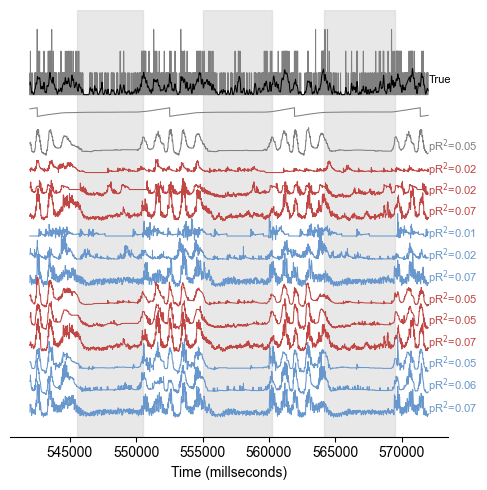

In [18]:
offset = 2  # vertical offset between traces

fig, ax = plt.subplots(figsize=(5, 5))
start=54000+200
end=57000+200
sf = -4 # scale factor for the y-axis
lw = 0.75
y = np.array(tcs_time[test_grid_cell_id]) # target variable is the test grid cell
ax.plot(np.arange(len(y))[start:end]*time_bs, y[start:end]*sf*0.5 + (offset*-2), label='True', color='grey', linewidth=lw)
ax.plot(np.arange(len(y))[start:end]*time_bs, y_smoothed[start:end]*sf*0.5 + (offset*-2), label='True', color='black', linewidth=lw)

ax.plot(np.arange(len(X))[start:end]*time_bs, X[start:end]*sf*0.001 + (offset*-1), label='True', color='grey', linewidth=lw)

ax.plot(np.arange(len(Y_hat_p))[start:end]*time_bs, Y_hat_p[start:end]*sf + offset, color='tab:grey', linewidth=lw, label='Position')
ax.plot(np.arange(len(Y_hat_g1))[start:end]*time_bs, Y_hat_g1[start:end]*sf + (offset*2), color='#c04744', linewidth=lw, label='Grid cell 10')
ax.plot(np.arange(len(Y_hat_g2))[start:end]*time_bs, Y_hat_g2[start:end]*sf + (offset*3), color='#c04744', linewidth=lw, label='Grid cell 11')
ax.plot(np.arange(len(Y_hat_gcs_top))[start:end]*time_bs, Y_hat_gcs_top[start:end]*sf + (offset*4), color='#c04744', linewidth=lw, label='Grid cells')
ax.plot(np.arange(len(Y_hat_ngs3))[start:end]*time_bs, Y_hat_ngs3[start:end]*sf + (offset*5), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2')
ax.plot(np.arange(len(Y_hat_ngs4))[start:end]*time_bs, Y_hat_ngs4[start:end]*sf + (offset*6), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 3')
ax.plot(np.arange(len(Y_hat_ngs_top))[start:end]*time_bs, Y_hat_ngs_top[start:end]*sf + (offset*7), color='#6897CD', linewidth=lw, label='Non-grid spatial cells')
ax.plot(np.arange(len(Y_hat_pos_g1))[start:end]*time_bs, Y_hat_pos_g1[start:end]*sf + (offset*8), color='#c04744', linewidth=lw, label='Grid cell 10 + Position')
ax.plot(np.arange(len(Y_hat_pos_g2))[start:end]*time_bs, Y_hat_pos_g2[start:end]*sf + (offset*9), color='#c04744', linewidth=lw, label='Grid cell 11 + Position')
ax.plot(np.arange(len(Y_hat_pos_gcs_top))[start:end]*time_bs, Y_hat_pos_gcs_top[start:end]*sf + (offset*10), color='#c04744', linewidth=lw, label='Grid cells + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs3))[start:end]*time_bs, Y_hat_pos_ngs3[start:end]*sf + (offset*11), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 2 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs4))[start:end]*time_bs, Y_hat_pos_ngs4[start:end]*sf + (offset*12), color='#6897CD', linewidth=lw, label='Non-grid spatial cell 3 + Position')
ax.plot(np.arange(len(Y_hat_pos_ngs_top))[start:end]*time_bs, Y_hat_pos_ngs_top[start:end]*sf + (offset*13), color='#6897CD', linewidth=lw, label='Non-grid spatial cells + Position')
ax.set_xlabel('Time (millseconds)')

# Annotate mean pR² values with superscript

ax.text(end*time_bs + 10, np.mean(y[start:end]*sf + (offset*-2)), 'True', va='center', fontsize=8, color='black')
ax.text(end*time_bs + 10, np.mean(Y_hat_p[start:end]*sf + offset), f'pR$^2$={np.nanmean(pR2_cv_p):.2f}', va='center', fontsize=8, color='tab:grey')
ax.text(end*time_bs + 10, np.mean(Y_hat_g1[start:end]*sf + (offset*2)), f'pR$^2$={np.nanmean(pR2_cv_g1):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_g2[start:end]*sf + (offset*3)), f'pR$^2$={np.nanmean(pR2_cv_g2):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_gcs_top[start:end]*sf + (offset*4)), f'pR$^2$={np.nanmean(pR2_cv_gcs_top):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs3[start:end]*sf + (offset*5)), f'pR$^2$={np.nanmean(pR2_cv_ngs3):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs4[start:end]*sf + (offset*6)), f'pR$^2$={np.nanmean(pR2_cv_ngs4):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_top[start:end]*sf + (offset*7)), f'pR$^2$={np.nanmean(pR2_cv_ngs_top):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g1[start:end]*sf + (offset*8)), f'pR$^2$={np.nanmean(pR2_cv_pos_g1):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_g2[start:end]*sf + (offset*9)), f'pR$^2$={np.nanmean(pR2_cv_pos_g2):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_gcs_top[start:end]*sf + (offset*10)), f'pR$^2$={np.nanmean(pR2_cv_pos_gcs_top):.2f}', va='center', fontsize=8, color='#c04744')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs3[start:end]*sf + (offset*11)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs3):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_pos_ngs4[start:end]*sf + (offset*12)), f'pR$^2$={np.nanmean(pR2_cv_pos_ngs4):.2f}', va='center', fontsize=8, color='#6897CD')
ax.text(end*time_bs + 10, np.mean(Y_hat_ngs_top[start:end]*sf + (offset*13)), f'pR$^2$={np.nanmean(pR2_cv_ngs_top):.2f}', va='center', fontsize=8, color='#6897CD')


# Find indices where X[start:end] is between 90 and 110
mask = (X[start:end].flatten() >= 90) & (X[start:end].flatten() <= 110)
if np.any(mask):
    xvals = np.arange(len(X))[start:end][mask] * time_bs
    # Shade the region(s) where the mask is True
    # If there are multiple contiguous regions, shade each
    from itertools import groupby
    from operator import itemgetter

    # Find contiguous regions
    idx = np.where(mask)[0]
    for k, g in groupby(enumerate(idx), lambda ix: ix[0] - ix[1]):
        group = list(map(itemgetter(1), g))
        x_start = np.arange(len(X))[start:end][group[0]] * time_bs
        x_end = np.arange(len(X))[start:end][group[-1]] * time_bs
        ax.axvspan(x_start, x_end, color='lightgrey', alpha=0.5, zorder=0)


#ax.legend()
# remove top, left and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_yticklabels([])
ax.set_yticks([])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_xgboost_example_traces.pdf', bbox_inches='tight', dpi=500)
plt.show()


In [19]:
def white_to_hex_cmap(hex_color, name='custom_cmap'):
    return LinearSegmentedColormap.from_list(name, ['#FFFFFF', hex_color])


using expected spikes for cell 26
using expected spikes for cell 29
using expected spikes for cell 30
using expected spikes for cell 33
using expected spikes for cell 34
using expected spikes for cell 65
using expected spikes for cell 194
using expected spikes for cell 198
using expected spikes for cell 214
using expected spikes for cell 389
n trials: 147
n trials: 147
hi


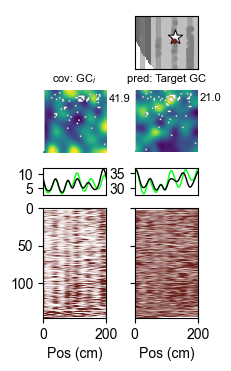

n trials: 147
n trials: 147
hi


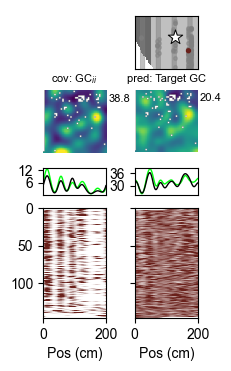

n trials: 147
n trials: 147
hi


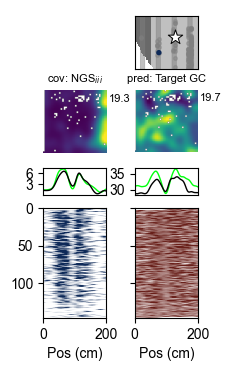

n trials: 147
n trials: 147
hi


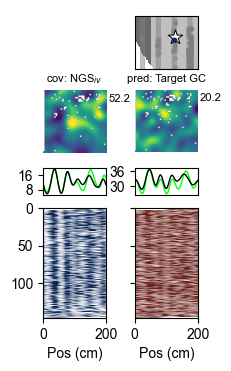

: 

In [ ]:
label = '_by_trial_type_'
source_path = '/Users/harryclark/Downloads/COHORT12/'
tl = 200

tcs, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs(mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path)
tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)

reconstructed_tcs = {}
trial_groups, trial_colors = get_trial_groups_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)
sorted_trial_indices, sorted_trial_colors = get_sorted_trials_and_colors(beh, last_ephys_bin, tl, bs, ignore_performance=True)

ids_to_test = [predictor_grid_cell_id_1, predictor_grid_cell_id_2, 
               predictor_non_grid_cell_id_3, predictor_non_grid_cell_id_4]
id_colors = ['#69201a', '#69201a', "#0d2958", '#0d2958']
id_names = ['GC$_i$', 'GC$_{ii}$', 'NGS$_{iii}$', 'NGS$_{iv}$']

for id, color, id_name in zip(ids_to_test, id_colors, id_names):
    # get the original
    tc = tcs[id]
    tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    tcz = zscore(tc)
    # get the reconstructed spikes for the test cell
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)

    for sort, colors, suffix in zip([None, sorted_trial_indices], [trial_colors, sorted_trial_colors], ['', '_sorted']):
        if sort is sorted_trial_indices:
            continue
        fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(rm_figsize[0]*2, rm_figsize[1]*2.5), 
                               sharex=False, height_ratios=[0.6, 0.6, 0.25, 1], width_ratios=[1,1])

        plot_firing_rate_map(ax[3,0], tc, bs=bs, tl=tl, p=95, sort_indices=sort, cmap=white_to_hex_cmap(color))
        plot_firing_rate_map(ax[3,1], tc_es, bs=bs, tl=tl, p=95, sort_indices=sort, cmap=white_to_hex_cmap('#69201a'))

        ax[3,0].set_xlabel('Pos (cm)')
        ax[3,1].set_xlabel('Pos (cm)')
        ax[3,1].set_yticklabels([])
        ax[2,1].set_xticks([])
        ax[2,0].set_xticks([])
        ax[2,0].set_xlim([0,200])
        ax[1,1].set_xlim([0,200])
        
        for group in np.unique(trial_groups):
            if len(trial_groups[trial_groups == group]) > 5:
                x, y = get_avg_profile(tc, bs, tl, mask=trial_groups==group)
                ax[2,0].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
                x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
                ax[2,1].plot(x, y, color=trial_colors[trial_groups==group][0], linewidth=1)
                ax[2,0].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=2))
                ax[2,1].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=2))
        ax[2,1].set_xlim([0,200])

        # plot the probe locations
        unique_colors = np.unique(annotation_colors)
        for color_ in unique_colors:
            border_points = extract_border(annotation_colors, color_, only_border=False)
            x_points = xs[border_points[:, 1]]
            y_points = ys[border_points[:, 0]]
            ax[0,1].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
        plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                       probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
        # plot cell locations 
        ax[0,1].scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        ax[0,1].scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)

        # highlight the target cell (id=214) with a white star, thinner black edge
        target_id = test_grid_cell_id
        target_row = all_by_anatomy[all_by_anatomy['cluster_id'] == target_id]
        if not target_row.empty:
            x_t, y_t = target_row['probe_x'].values[0], target_row['probe_y'].values[0]
            ax[0,1].scatter(x_t, y_t, marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=11)

        # highlight the covariate cell (id) with a black circle (on top of the star if same location)
        cov_row = all_by_anatomy[all_by_anatomy['cluster_id'] == id]
        if not cov_row.empty:
            x_c, y_c = cov_row['probe_x'].values[0], cov_row['probe_y'].values[0]
            from matplotlib.patches import Circle
            circ2 = Circle((x_c, y_c), radius=20, edgecolor=color, facecolor='none', lw=2, zorder=12)
            ax[0,1].add_patch(circ2)

        ax[0,1].set_ylim([650, 1500])
        ax[0,1].set_xlim([-100, 900])
        ax[0,1].spines['top'].set_visible(True)
        ax[0,1].spines['right'].set_visible(True)
        ax[0,1].spines['bottom'].set_visible(True)
        ax[0,1].spines['left'].set_visible(True)

    # plot open field rate maps and reconstructions
    plot_open_field_rate_map_optimal_ax(ax[1,0], id, mouse, day, all, source_path=None)
    ax[1,1].imshow(tcs_expected_spikes_of[id], cmap='viridis')
    ax[1,1].axis('off')
    ax[1,1].set_xlim(0,40)
    ax[1,1].set_ylim(0,40)
    ax[1,1].invert_yaxis()
    ax[0,0].axis('off')

    max_val0 = np.nanmax(tcs[id])
    ax[1,0].text(
        41, 2, f"{max_val0:.1f}",
        fontsize=8, color='black', ha='left', va='top'
    )
    max_val1 = np.nanmax(tcs_expected_spikes_of[id])
    ax[1,1].text(
        41, 2, f"{max_val1:.1f}",
        fontsize=8, color='black', ha='left', va='top'
    )

    ax[1,0].set_title(f"cov: {id_name}", fontsize=8)
    ax[1,1].set_title(f"pred: Target GC", fontsize=8)

    plt.subplots_adjust(wspace=0.45)
    fig.savefig(f'{figpath_rm}/M{mouse}D{day}{label}{id}{suffix}_with_avg_and_reconstruction.pdf', dpi=300, bbox_inches='tight')
    plt.show()

using expected spikes for cell 26
using expected spikes for cell 29
using expected spikes for cell 30
using expected spikes for cell 33
using expected spikes for cell 34
using expected spikes for cell 65
using expected spikes for cell 194
using expected spikes for cell 198
using expected spikes for cell 214
using expected spikes for cell 389
using expected spikes for cell 26
using expected spikes for cell 29
using expected spikes for cell 30
using expected spikes for cell 33
using expected spikes for cell 34
using expected spikes for cell 65
using expected spikes for cell 194
using expected spikes for cell 198
using expected spikes for cell 214
using expected spikes for cell 389
n trials: 147
hi


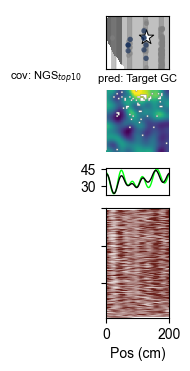

n trials: 147
hi


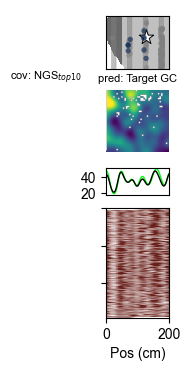

n trials: 147
hi


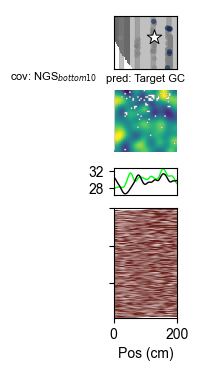

n trials: 147
hi


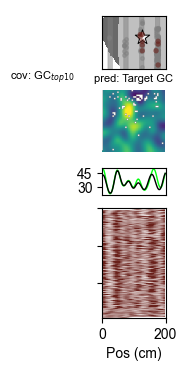

n trials: 147
hi


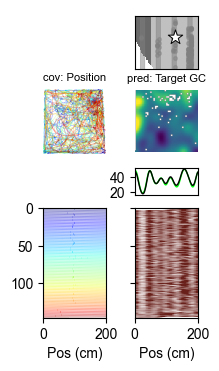

In [86]:
names = ['ngs_top','ngs_top2','ngs_bottom','gcs_top', '_pos']
id_names = ['NGS$_{top10}$','NGS$_{top10}$','NGS$_{bottom10}$','GC$_{top10}$', 'Position']
id_colors = ['#0d2958', '#0d2958', '#0d2958','#69201a',"#000000"]
ids_to_test = [ngs_top_cluster_ids, ngs_top_cluster_ids2, ngs_bottom_cluster_ids, gcs_top_cluster_ids, []]
pseudo_ids = [26, 29, 30, 33, 34]  # pseudo ids to use for the probe plot

# use the cluster_ids for the ns group as a trick to push it though the reconstruction function
expected_spikes[26] = Y_hat_ngs_top
expected_spikes[29] = Y_hat_ngs_top2
expected_spikes[30] = Y_hat_ngs_bottom
expected_spikes[33] = Y_hat_gcs_top
expected_spikes[34] = Y_hat_p

expected_spikes_of[26] = Y_hat_ngs_top_OF
expected_spikes_of[29] = Y_hat_ngs_top2_OF
expected_spikes_of[30] = Y_hat_ngs_bottom_OF
expected_spikes_of[33] = Y_hat_gcs_top_OF
expected_spikes_of[34] = Y_hat_p_OF

# reconstruct using the expected spikes
tcs_expected_spikes, _, _ , last_ephys_bin, beh, _ = compute_vr_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, vr_type='VR', source_path=source_path, expected_spikes=expected_spikes)

tcs_expected_spikes_of, _ , _, _, _ = compute_of_tcs_using_expected_spikes(
    mouse, day, apply_zscore=False, optimal_shift=gcs.travel[0], source_path=None, expected_spikes=expected_spikes_of)

for id, color, test_ids, name, id_name in zip(pseudo_ids, id_colors, ids_to_test, names, id_names):

    # get the original
    #tc = tcs[id]
    #tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
    #tc = tc[:last_ephys_bin] # only want bins with ephys data in it
    #tcz = zscore(tc)
    # get the reconstructed spikes for the test cell
    tc_es = tcs_expected_spikes[id]
    tc_es = gaussian_filter(np.nan_to_num(tc_es).astype(np.float64), sigma=2.5)
    tc_es = tc_es[:last_ephys_bin] # only want bins with ephys data in it
    tcz_es = zscore(tc_es)

    for sort, colors, suffix in zip([None, sorted_trial_indices], [trial_colors, sorted_trial_colors], ['', '_sorted']):
        if sort is sorted_trial_indices:
            continue

        fig, ax = plt.subplots(ncols=2, nrows=4, figsize=(rm_figsize[0]*2, rm_figsize[1]*2.5), 
                               sharex=False, height_ratios=[0.6, 0.6, 0.25, 1], width_ratios=[1,1])

        #plot_firing_rate_map(ax[1,0], tc, bs=bs, tl=tl,p=95, sort_indices=sort, cmap=white_to_hex_cmap(color))
        plot_firing_rate_map(ax[3,1], tc_es, bs=bs, tl=tl,p=95, sort_indices=sort, cmap=white_to_hex_cmap('#69201a'))
        ax[3,0].set_xlabel('Pos (cm)')
        ax[3,1].set_xlabel('Pos (cm)')
        ax[3,1].set_yticklabels([])
        ax[2,1].set_xticks([])
        for group in np.unique(trial_groups):
            if len(trial_groups[trial_groups == group])>5:
                x, y = get_avg_profile(tc_es, bs, tl, mask=trial_groups==group)
                ax[2,1].plot(x,y, color=trial_colors[trial_groups==group][0], linewidth=1)
                ax[2,1].yaxis.set_major_locator(MaxNLocator(integer=True, nbins=2))
        ax[2,1].set_xlim([0,200])
        
        # plot the probe locations
        unique_colors = np.unique(annotation_colors)
        for color_ in unique_colors:
            border_points = extract_border(annotation_colors, color_, only_border=False)
            x_points = xs[border_points[:, 1]]
            y_points = ys[border_points[:, 0]]
            ax[0,1].scatter(x_points, y_points, color=color_, s=1, label=color_, rasterized=True)
        plot_NP2_probe(ax[0,1], sorting_analyzer_path='/Users/harryclark/Downloads/kilosort4_sa', 
                       probe_alpha=0.5, contacts_alpha=0.0, probe_color='grey', probe_edgecolor='black')
        # plot cell locations 
        ax[0,1].scatter(ngs.probe_x.values, ngs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)
        ax[0,1].scatter(gcs.probe_x.values, gcs.probe_y.values, marker='o', color="grey", alpha=0.4, s=7)

        # highlight the target cell (id=214) with a white star, thinner black edge
        target_id = test_grid_cell_id
        target_row = all_by_anatomy[all_by_anatomy['cluster_id'] == target_id]
        if not target_row.empty:
            x_t, y_t = target_row['probe_x'].values[0], target_row['probe_y'].values[0]
            ax[0,1].scatter(x_t, y_t, marker='*', s=120, color='white', edgecolor='black', linewidth=0.7, zorder=11)

        # highlight the covariate cell (id) with a black circle (on top of the star if same location)
        cov_row = all_by_anatomy[np.isin(all_by_anatomy['cluster_id'], test_ids)]
        if not cov_row.empty:
            for _, row in cov_row.iterrows():
                x_c, y_c = row['probe_x'], row['probe_y']
                from matplotlib.patches import Circle
                circ2 = Circle((x_c, y_c), radius=20, edgecolor=color, facecolor='none', lw=2, alpha=0.6, zorder=12)
                ax[0,1].add_patch(circ2)

        ax[0,1].set_ylim([650, 1500])
        ax[0,1].set_xlim([-100, 900])
        ax[0,1].spines['top'].set_visible(True)
        ax[0,1].spines['right'].set_visible(True)
        ax[0,1].spines['bottom'].set_visible(True)
        ax[0,1].spines['left'].set_visible(True)
        ax[0,0].axis('off')
        
    percentile99 = np.nanpercentile(tcs_expected_spikes_of[id], 99)
    ax[1,1].imshow(tcs_expected_spikes_of[id], cmap='viridis', vmax=percentile99)
    ax[1,1].axis('off')
    ax[1,1].set_xlim(0,40)
    ax[1,1].set_ylim(0,40)
    ax[1,1].invert_yaxis()
    ax[0,0].axis('off')
    ax[1,0].axis('off')
    ax[1,0].set_title(f"cov: {id_name}", fontsize=8)
    ax[1,1].set_title(f"pred: Target GC", fontsize=8)
    ax[2,0].axis('off')

    if id_name == 'Position':
        from matplotlib.collections import LineCollection
        #ax[1,0].plot(x_pos_in_time_OF, y_pos_in_time_OF, color='black', linewidth=0.2, alpha=0.5)
        #ax[3,0].plot(pos_in_time, trial_number_in_time, color='black', linewidth=0.2, alpha=0.5)

        points = np.array([x_pos_in_time_OF, y_pos_in_time_OF]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        norm = plt.Normalize(0, len(x_pos_in_time_OF)-1)
        lc = LineCollection(segments, cmap='jet', norm=norm)
        lc.set_array(np.arange(len(x_pos_in_time_OF)-1))
        lc.set_linewidth(0.5)
        lc.set_alpha(0.3)
        lc.set_rasterized(True)
        ax[1,0].add_collection(lc)
        #ax[1,0].plot(x_pos_in_time_OF, y_pos_in_time_OF, color='black', linewidth=0.2, alpha=0.5)
        ax[1,0].set_xlim(140,600)
        ax[1,0].set_ylim(np.nanmin(y_pos_in_time_OF), np.nanmax(y_pos_in_time_OF))

        trial_number_in_time = trial_number_in_time-np.nanmin(trial_number_in_time)
        points = np.array([pos_in_time, trial_number_in_time]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        norm = plt.Normalize(0, len(pos_in_time)-1)
        lc = LineCollection(segments, cmap='jet', norm=norm)
        lc.set_array(np.arange(len(pos_in_time)-1))
        lc.set_linewidth(0.2)
        lc.set_alpha(0.5)
        lc.set_rasterized(True)
        ax[3,0].add_collection(lc)
        ax[3,0].set_xlim(0,200)
        ax[3,0].set_ylim(np.nanmin(trial_number_in_time), np.nanmax(trial_number_in_time))
        ax[3,0].invert_yaxis()
        
    else:
        ax[3,0].axis('off')
        
    plt.subplots_adjust(wspace=0.45)
    fig.savefig(f'{figpath_rm}/M{mouse}D{day}_{name}_with_avg_and_reconstruction.pdf', dpi=1000, bbox_inches='tight')
    plt.show()

n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147


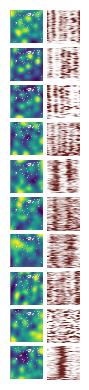

n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147


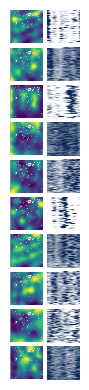

n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147


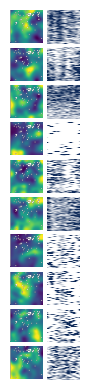

In [22]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.stats import zscore
import numpy as np
id_colors = ['#69201a', "#0d2958", '#0d2958']
names = ['gcs_top', 'ngs_top', 'ngs_bottom']
ids_to_test = [gcs_top_cluster_ids, ngs_top_cluster_ids, ngs_bottom_cluster_ids]

for ids, color, name in zip(ids_to_test, id_colors, names):
    fig, axs = plt.subplots(10, 2, figsize=(rm_figsize[0], 
                                           rm_figsize[1]*2.5), sharex='col', sharey=False)
    for i, id in enumerate(ids[:10]):
        row = i
        col = 1
        ax = axs[row, col]
        tc = tcs[id]
        tc = gaussian_filter(np.nan_to_num(tc).astype(np.float64), sigma=2.5)
        tc = tc[:last_ephys_bin]  # only want bins with ephys data in it
        tcz = zscore(tc)
        ax.axis('off')
        plot_open_field_rate_map_optimal_ax(axs[i,0], id, mouse, day, all, source_path=None)
        axs[i,0].axis('off')
        axs[i,0].set_xlim(0,40)
        axs[i,0].set_ylim(0,40)
        axs[i,0].invert_yaxis()
        plot_firing_rate_map(ax, tc, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(color))
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.1)
    fig.savefig(f'{figpath_rm}/M{mouse}D{day}_{name}_10_cell_rate_maps.pdf', dpi=1000, bbox_inches='tight')
    plt.show()

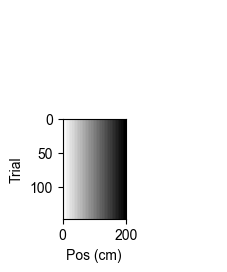

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Example: create a heatmap where each row is a trial and each column is the position (in cm)
n_trials = 147
n_pos_bins = 40
pos_bins = np.linspace(0, 200, n_pos_bins + 1)  # position bin edges

# Simulate position for each trial: each trial is a row, each column is a position bin
# Here, the value in the heatmap is just the position (for demonstration)
position_heatmap = np.tile((pos_bins[:-1] + pos_bins[1:]) / 2, (n_trials, 1))

rm_figsize = (1, 1.6) 

fig, ax = plt.subplots(
    ncols=2, nrows=3,
    figsize=(rm_figsize[0]*2, rm_figsize[1]*1.7),
    sharex=False,
    gridspec_kw={'height_ratios': [0.6, 0.25, 1], 'width_ratios': [1, 1]}
)

# Plot the heatmap on ax[2,0]
ax_hm = ax[2, 0]
mesh = ax_hm.pcolormesh(
    pos_bins,
    np.arange(n_trials + 1),
    position_heatmap,
    cmap='binary',
    shading='auto',
    rasterized=True,
)
ax_hm.set_xlabel('Pos (cm)')
ax_hm.set_ylabel('Trial')
ax_hm.set_xlim(pos_bins[0], pos_bins[-1])
ax_hm.set_ylim(0, n_trials)
ax_hm.invert_yaxis()

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[1,1].axis('off')
ax[1,0].axis('off')
ax[2,1].axis('off')
plt.subplots_adjust(wspace=0.45)
plt.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/M{mouse}D{day}_position_heatmap.pdf', bbox_inches='tight', dpi=500)
plt.show()

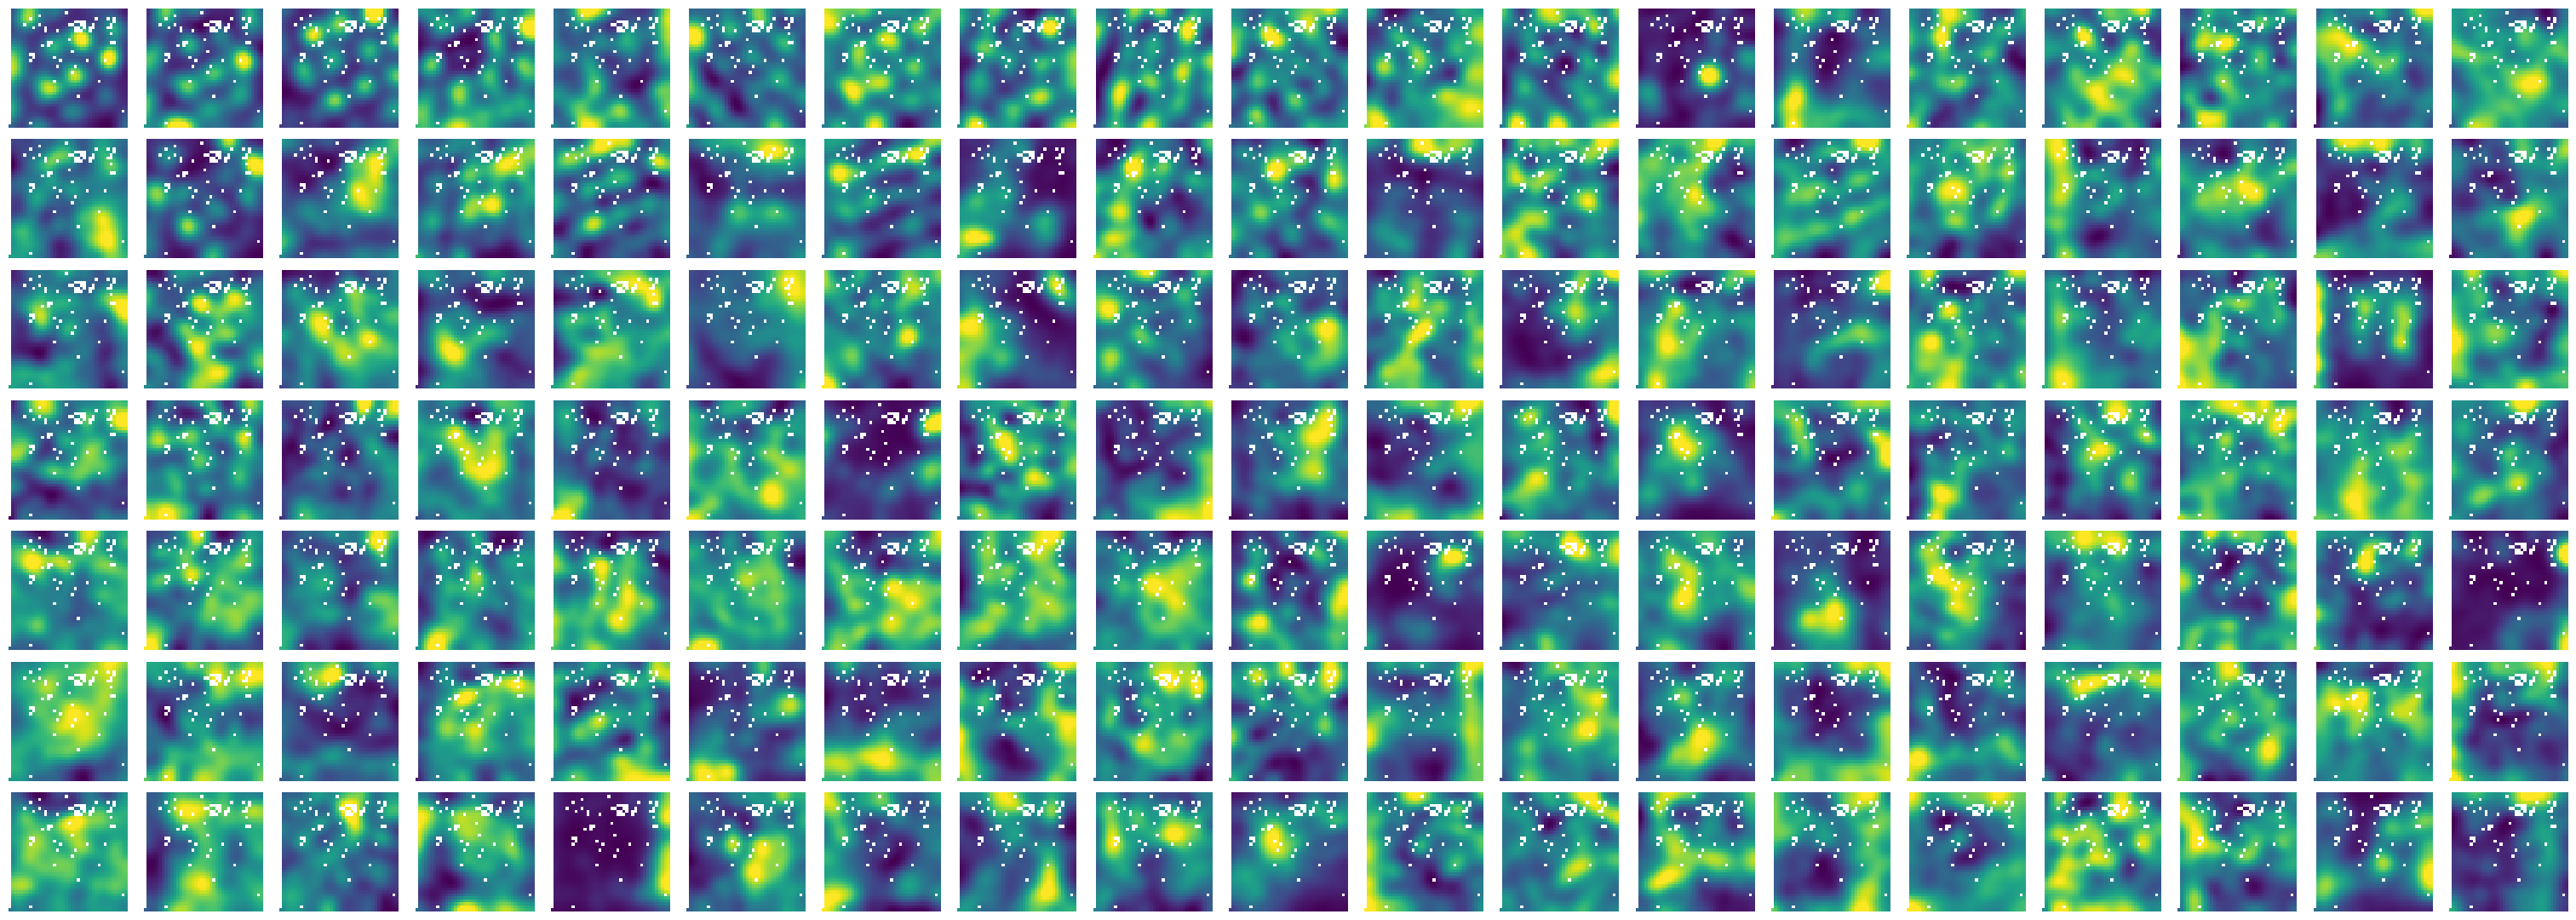

In [32]:
# ...existing code...
import math
import matplotlib.pyplot as plt
import numpy as np

def get_sort_key_df(df, id_col='cluster_id', score_cols=('grid_score_opt','grid_score','gridness','grid_score_of')):
    """
    Return a dict {id: score} using the first available score column from score_cols.
    If none available, return zeros for all ids.
    """
    for col in score_cols:
        if col in df.columns:
            scores = df.set_index(id_col)[col].to_dict()
            return scores
    # fallback zeros
    return {int(i): 0.0 for i in df[id_col].astype(int).values}

def plot_all_openfield_combined(gcs_df, ngs_df, mouse, day, all_df, outpath,
                                ncols=19, figsize_scale=(1.6,1.6), cmap=None):
    """
    Create one combined figure with grid cells first (sorted by grid score),
    then starting on a new row the non-grid cells (sorted by same score or zeros).
    Uses plot_open_field_rate_map_optimal_ax(ax, cid, mouse, day, all_df, source_path=None).
    """
    # prepare id lists and sort by grid score (if available)
    gcs_ids = [int(x) for x in sorted(set(gcs_df['cluster_id'].astype(int)))]
    ngs_ids = [int(x) for x in sorted(set(ngs_df['cluster_id'].astype(int)))]
    # get scores from union dataframe (prefer gcs_df then all_df)
    scores = {}
    scores.update(get_sort_key_df(all_df))       # use all_df if it contains scores
    scores.update(get_sort_key_df(gcs_df))       # override with gcs_df if present
    # sort descending (largest grid score first)
    gcs_ids_sorted = sorted(gcs_ids, key=lambda cid: scores.get(cid, 0.0), reverse=True)
    ngs_ids_sorted = sorted(ngs_ids, key=lambda cid: scores.get(cid, 0.0), reverse=True)

    # ensure ngs start on a new row: compute rows separately
    rows_gcs = math.ceil(len(gcs_ids_sorted) / ncols) if len(gcs_ids_sorted)>0 else 0
    rows_ngs = math.ceil(len(ngs_ids_sorted) / ncols) if len(ngs_ids_sorted)>0 else 0
    if rows_gcs == 0 and rows_ngs == 0:
        print("No ids to plot.")
        return

    total_rows = rows_gcs + rows_ngs
    fig_h = total_rows * figsize_scale[1]
    fig_w = ncols * figsize_scale[0]
    fig, axs = plt.subplots(total_rows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    axs_flat = axs.ravel()

    # helper to turn off unused axes at the end
    used_axes = []

    # plot grids first
    for i, cid in enumerate(gcs_ids_sorted):
        row = i // ncols
        col = i % ncols
        ax = axs[row, col]
        used_axes.append((row, col))
        try:
            plot_open_field_rate_map_optimal_ax(ax, cid, mouse, day, all_df, source_path=None)
            #ax.set_title(f"GC id={cid}", fontsize=7)
        except Exception as e:
            ax.axis('off')
            ax.text(0.5, 0.5, f"err {cid}\n{e}", ha='center', va='center', fontsize=6)

    # start non-grid on a fresh row (even if previous row partially filled)
    start_idx = rows_gcs * ncols
    for j, cid in enumerate(ngs_ids_sorted):
        idx = start_idx + j
        row = idx // ncols
        col = idx % ncols
        ax = axs[row, col]
        used_axes.append((row, col))
        try:
            plot_open_field_rate_map_optimal_ax(ax, cid, mouse, day, all_df, source_path=None)
            #ax.set_title(f"NGS id={cid}", fontsize=7)
        except Exception as e:
            ax.axis('off')
            ax.text(0.5, 0.5, f"err {cid}\n{e}", ha='center', va='center', fontsize=6)

    # turn off any unused axes
    for r in range(total_rows):
        for c in range(ncols):
            if (r,c) not in used_axes:
                axs[r,c].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    #plt.suptitle(f"M{mouse}D{day} open-field maps — GC then NGS (sorted by grid score)", fontsize=10)
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


# usage
outdir = "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost"
combined_out = f"{outdir}/M{mouse}D{day}_openfield_GC_then_NGS_optshift_combined.pdf"
plot_all_openfield_combined(gcs, ngs, mouse, day, all, combined_out, ncols=19, figsize_scale=(1.6,1.6))
# ...existing code...

n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n trials: 147
n tria

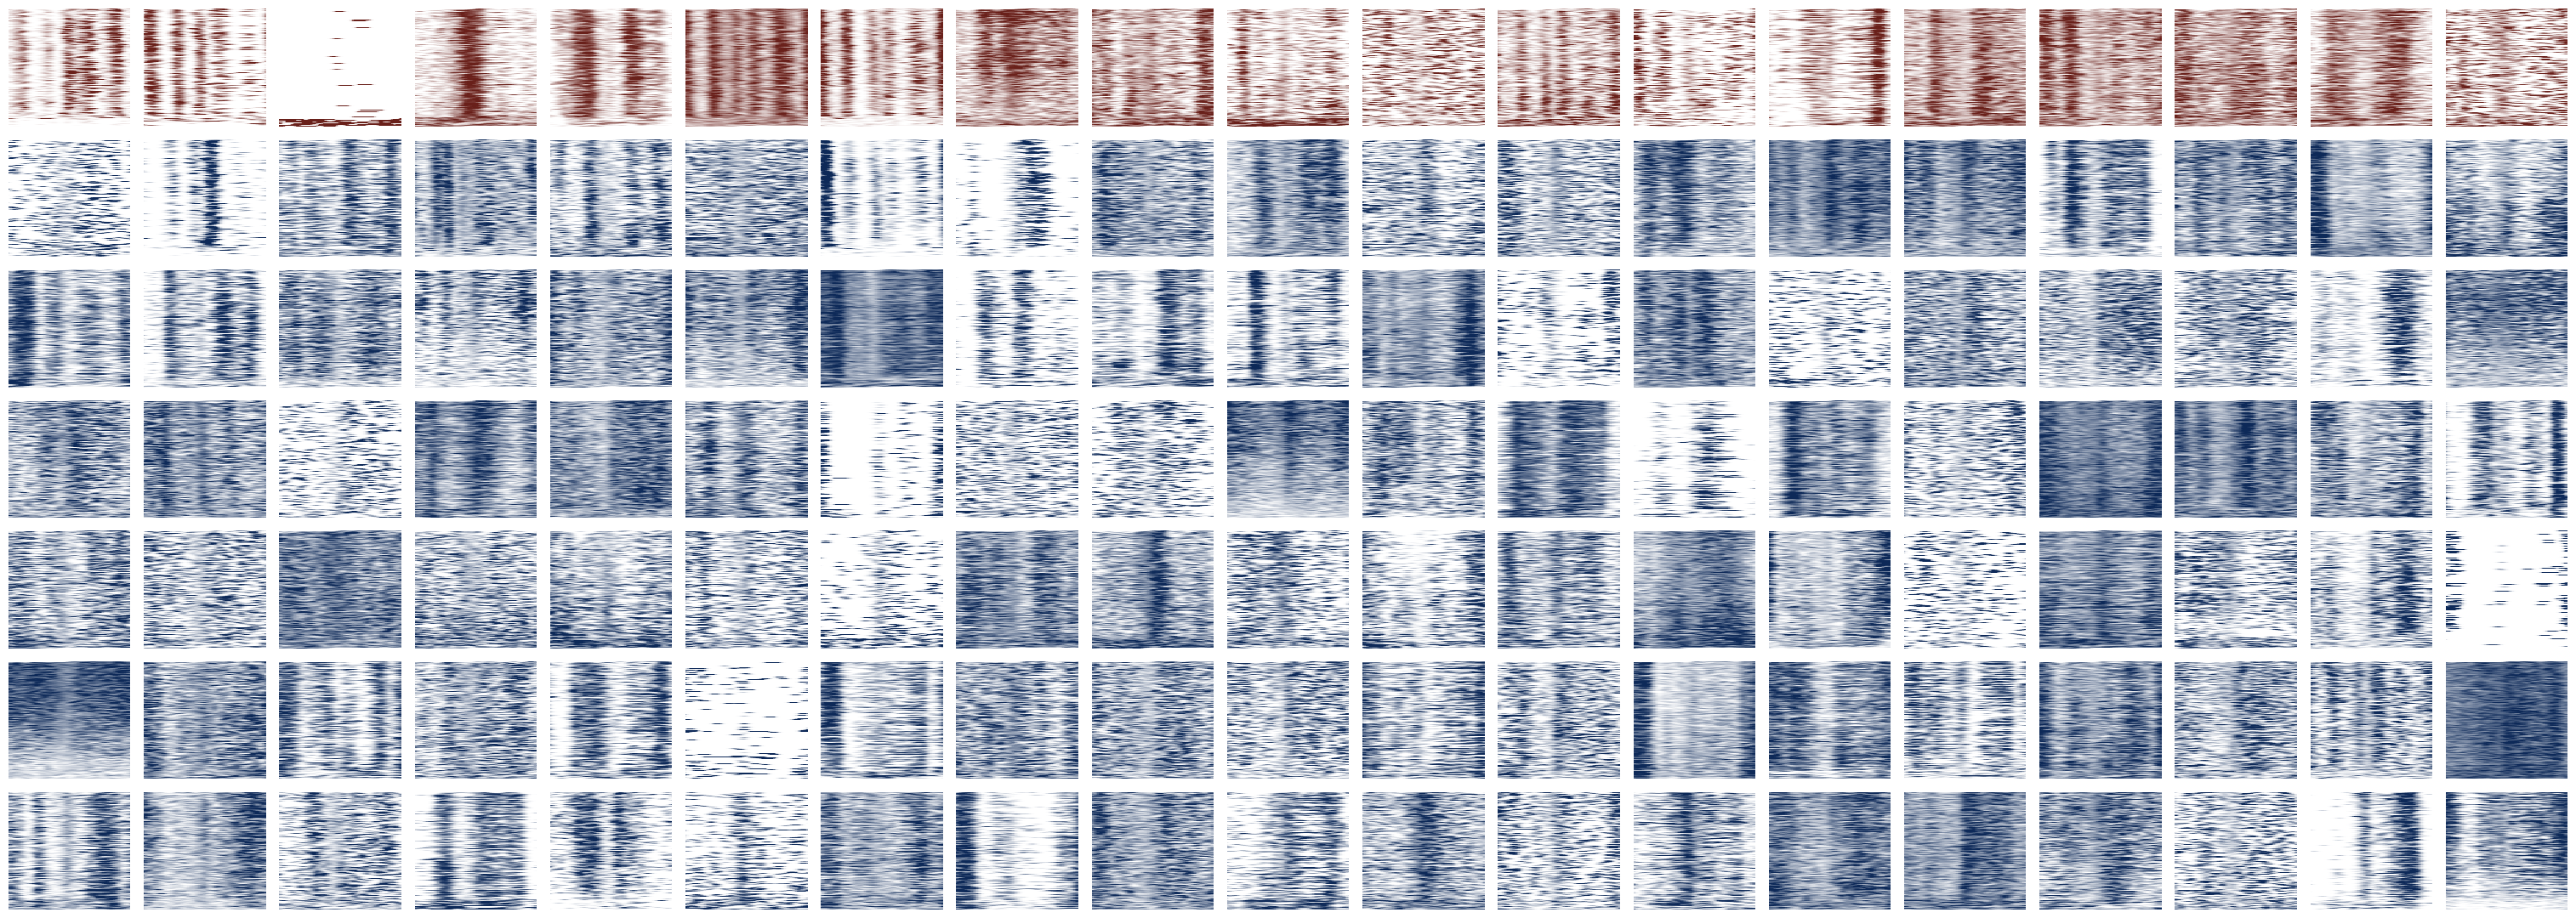

In [31]:
import math
import matplotlib.pyplot as plt
import numpy as np

def plot_all_vr_combined(gcs_df, ngs_df, tcs_dict, mouse, day, outpath,
                         ncols=19, figsize_scale=(1.6,1.6),
                         bs=bs, tl=tl, cmap_gc='#69201a', cmap_ngs='#0d2958'):
    """
    Combined VR rate-map figure: grid cells first (sorted by grid score),
    then starting on a new row the non-grid cells (sorted by same score).
    Expects tcs_dict mapping cluster_id -> trial-averaged tuning curve (1D array).
    Uses plot_firing_rate_map(ax, tc, bs=bs, tl=tl, p=95, cmap=...) which is available in the notebook.
    This version removes axis ticks and spines for a cleaner, image-only layout
    while keeping the subplot titles.
    """
    # prepare ids and scores
    gcs_ids = [int(x) for x in sorted(set(gcs_df['cluster_id'].astype(int)))]
    ngs_ids = [int(x) for x in sorted(set(ngs_df['cluster_id'].astype(int)))]
    scores = {}
    scores.update(get_sort_key_df(all))   # try all (global) first
    scores.update(get_sort_key_df(gcs_df))# override with gcs if present

    gcs_ids_sorted = sorted(gcs_ids, key=lambda cid: scores.get(cid, 0.0), reverse=True)
    ngs_ids_sorted = sorted(ngs_ids, key=lambda cid: scores.get(cid, 0.0), reverse=True)

    rows_gcs = math.ceil(len(gcs_ids_sorted) / ncols) if len(gcs_ids_sorted)>0 else 0
    rows_ngs = math.ceil(len(ngs_ids_sorted) / ncols) if len(ngs_ids_sorted)>0 else 0
    if rows_gcs == 0 and rows_ngs == 0:
        print("No VR ids to plot.")
        return

    total_rows = rows_gcs + rows_ngs
    fig_w = ncols * figsize_scale[0]
    fig_h = total_rows * figsize_scale[1]
    fig, axs = plt.subplots(total_rows, ncols, figsize=(fig_w, fig_h), squeeze=False)
    used_axes = []

    def remove_axes_decor(ax, keep_title=True):
        # hide ticks and spines but preserve the title
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        # keep axis background / image visible (do not call ax.axis('off'))
        if not keep_title:
            ax.set_title('')

    # plot grid cells
    for i, cid in enumerate(gcs_ids_sorted):
        row = i // ncols
        col = i % ncols
        ax = axs[row, col]
        used_axes.append((row, col))
        try:
            tc = tcs_dict.get(cid, None)
            if tc is None:
                raise KeyError(f"tc for id {cid} not found in provided tcs_dict")
            plot_firing_rate_map(ax, tc, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(cmap_gc))
            #ax.set_title(f"GC {cid}", fontsize=7)
            ax.set_xlim(0, tl)
            remove_axes_decor(ax, keep_title=True)
        except Exception as e:
            ax.axis('off')
            ax.text(0.5, 0.5, f"err {cid}\n{e}", ha='center', va='center', fontsize=6)

    # start non-grid on new row
    start_idx = rows_gcs * ncols
    for j, cid in enumerate(ngs_ids_sorted):
        idx = start_idx + j
        row = idx // ncols
        col = idx % ncols
        ax = axs[row, col]
        used_axes.append((row, col))
        try:
            tc = tcs_dict.get(cid, None)
            if tc is None:
                raise KeyError(f"tc for id {cid} not found in provided tcs_dict")
            plot_firing_rate_map(ax, tc, bs=bs, tl=tl, p=95, cmap=white_to_hex_cmap(cmap_ngs))
            #ax.set_title(f"NGS {cid}", fontsize=7)
            ax.set_xlim(0, tl)
            remove_axes_decor(ax, keep_title=True)
        except Exception as e:
            ax.axis('off')
            ax.text(0.5, 0.5, f"err {cid}\n{e}", ha='center', va='center', fontsize=6)

    # turn off unused axes
    for r in range(total_rows):
        for c in range(ncols):
            if (r,c) not in used_axes:
                axs[r,c].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.96)
    #plt.suptitle(f"M{mouse}D{day} VR maps — GC then NGS (sorted by grid score)", fontsize=10)
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# usage
outdir = "/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost"
combined_vr_out = f"{outdir}/M{mouse}D{day}_vr_GC_then_NGS_combined.pdf"
# call with the tcs dict computed earlier in the notebook (variable name: tcs)
plot_all_vr_combined(gcs, ngs, tcs, mouse, day, combined_vr_out, ncols=19, figsize_scale=(1.6,1.6))


In [57]:
session = 'OF1'
of1_folder = f'{source_path}M{mouse}/D{day:02}/{session}/'
all_grid_scores = pd.read_parquet(of1_folder + "tuning_scores/shifted_grid_score_manual_smooth.parquet")
all_spatial_info = pd.read_parquet(of1_folder + "tuning_scores/shifted_spatial_information_manual_smooth.parquet")


appendix 1 hyperparameter search

In [ ]:
from hyperopt import fmin, hp, Trials, tpe, STATUS_OK

# Makes sure these are in model.params, otherwise you'll get a key error
space4rf = {
    'silent': 1,
    'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2, 0.3]),
    'min_child_weight': hp.choice('min_child_weight', [1, 2, 5, 10]),
    'n_estimators': hp.choice('n_estimators', [100, 300, 500, 700, 1000]),
    'subsample': hp.choice('subsample', [0.5, 0.6, 0.7, 0.8, 1.0]),
    'max_depth': hp.choice('max_depth', [3, 5, 7, 9]),
    'gamma': hp.choice('gamma', [0, 0.1, 0.3, 0.5, 1.0]),
}

#object that holds iteration results
trials = Trials()

#define model
xgb_history = MLencoding(tunemodel = 'xgboost',
                         cov_history = False, spike_history=True, # We can choose!
                         window = time_bs, #this dataset has 50ms time bins
                         n_filters = 5,
                         max_time = int(time_bs*10))

#function to minimize
def fnc(params):
    print(params)

    # make sure parameters are integers that need to be. 
    params['silent'] = int(params['silent'])
    params['n_estimators'] = int(params['n_estimators'])
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    xgb_history.set_params(params)
    
    # Remember that X and y have been defined above.
    Y_hat, PR2s = xgb_history.fit_cv(X,y, n_cv = 5, verbose = 0, continuous_folds = True)

    # return negative since hyperopt always minimizes the function
    return -np.mean(PR2s)

hyperoptBest = fmin(fnc, space4rf, algo=tpe.suggest, max_evals=500, 
                    trials=trials, return_argmin=False)


In [ ]:
hyperoptBest

In [83]:
def plot_rate_map_with_shifts(cluster_id, mouse, day, cell_type='grid', shifts=[-10, 0, 10], figpath='', source_path=None):
    """
    Plot open field rate maps for a single cell with different optimal shifts.
    
    Parameters:
    -----------
    cluster_id : int
        The cluster ID of the cell to plot
    mouse : int
        Mouse ID
    day : int
        Day ID
    cell_type : str
        Type of cell ('grid' or 'non-grid')
    shifts : list
        List of shift values to apply
    figpath : str
        Path to save figures
    source_path : str
        Source path for data files
    """
    if source_path is None:
        source_path = '/Users/harryclark/Downloads/COHORT12/'
    
    session = 'OF1'
    of1_folder = f'{source_path}M{mouse}/D{day:02}/{session}/'
    shifted_grid_path = of1_folder + "tuning_scores/shifted_grid_score.parquet"
    shifted_spatial_path = of1_folder + "tuning_scores/shifted_spatial_information.parquet"
    
    spikes_path = of1_folder + f"sub-{mouse}_day-{day:02}_ses-{session}_srt-kilosort4_clusters.npz"
    beh_path = of1_folder + f"sub-{mouse}_day-{day:02}_ses-{session}_beh.nwb"
    
    # Load data
    shifted_grid_scores_of1 = pd.read_parquet(shifted_grid_path)
    shifted_spatial_info_of1 = pd.read_parquet(shifted_spatial_path)
    beh_OF = nap.load_file(beh_path)
    clusters_OF = nap.load_file(spikes_path)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(5, 2.5))
    fig.suptitle(f'{cell_type.title()} Cell {cluster_id} - M{mouse}D{day}', fontsize=14)
    
    for i, shift in enumerate(shifts):
        ax = axes[i]
        
        # Apply shift to position data
        position = np.stack([beh_OF['P_x'], beh_OF['P_y']], axis=1)
        beh_lag = compute_travel_projected(["P_x", "P_y"], position, position, shift)
        position_lagged = np.stack([beh_lag['P_x'], beh_lag['P_y']], axis=1)
        
        # Compute 2D tuning curve
        tc = nap.compute_2d_tuning_curves(nap.TsGroup([clusters_OF[cluster_id]]), position_lagged, nb_bins=(40,40))[0]
        tc = gaussian_filter_nan(tc[0], sigma=(2.5,2.5))
        
        # Get grid score for this shift if available
        grid_score_row = shifted_grid_scores_of1[
            (shifted_grid_scores_of1.cluster_id == cluster_id) & 
            (shifted_grid_scores_of1.travel == shift)
        ]
        # get spatial information for this shift if available
        spatial_info_row = shifted_spatial_info_of1[    
            (shifted_spatial_info_of1.cluster_id == cluster_id) & 
            (shifted_spatial_info_of1.travel == shift)
        ]
         # Prepare score text
        
        if len(grid_score_row) > 0:
            grid_score = grid_score_row.grid_score.values[0]
            spatial_score = spatial_info_row.spatial_information.values[0]
            score_text = f'GS: {grid_score:.2f} \n SI: {spatial_score:.2f}'
        else:
            score_text = 'N/A'
        
        # Clip at 99th percentile for better visualization
        tc = np.clip(tc, a_min=0, a_max=np.nanpercentile(tc, 99))
        
        # Plot rate map
        im = ax.imshow(tc, cmap='viridis', aspect='equal')
        ax.set_title(f'{score_text}')
        ax.axis('off')

    plt.subplots_adjust(wspace=0.2)
    plt.tight_layout()
    
    # Save figure
    if figpath:
        filename = f'M{mouse}D{day}_{cell_type}_cell_{cluster_id}_rate_maps_shifts.pdf'
        plt.savefig(f'{figpath}/{filename}', dpi=300, bbox_inches='tight')
    
    plt.show()
    return fig


def plot_all_cells_with_shifts(gcs_df, ngs_df, mouse, day, figpath='', source_path=None, max_cells_per_type=10):
    """
    Plot rate maps with shifts for all grid and non-grid cells.
    
    Parameters:
    -----------
    gcs_df : DataFrame
        Grid cells dataframe
    ngs_df : DataFrame  
        Non-grid spatial cells dataframe
    mouse : int
        Mouse ID
    day : int
        Day ID
    figpath : str
        Path to save figures
    source_path : str
        Source path for data files
    max_cells_per_type : int
        Maximum number of cells to plot per type
    """
    # Plot grid cells
    print(f"Plotting grid cells (max {max_cells_per_type})...")
    grid_cells = gcs_df.cluster_id.values[:max_cells_per_type]
    for cluster_id in grid_cells:
        plot_rate_map_with_shifts(cluster_id, mouse, day, cell_type='grid',     
                                figpath=figpath, source_path=source_path)
    
    # Plot non-grid spatial cells
    print(f"Plotting non-grid spatial cells (max {max_cells_per_type})...")
    ngs_cells = ngs_df.cluster_id.values[:max_cells_per_type]
    for cluster_id in ngs_cells:
        plot_rate_map_with_shifts(cluster_id, mouse, day, cell_type='non-grid', 
                                figpath=figpath, source_path=source_path)

Plotting grid cells (max 20)...


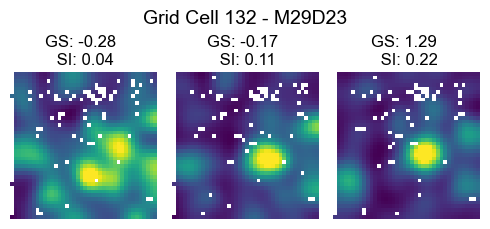

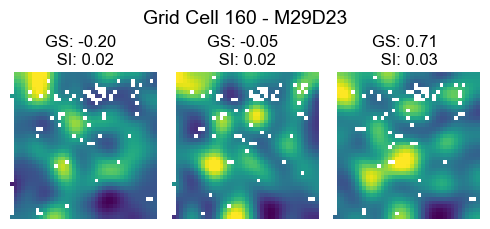

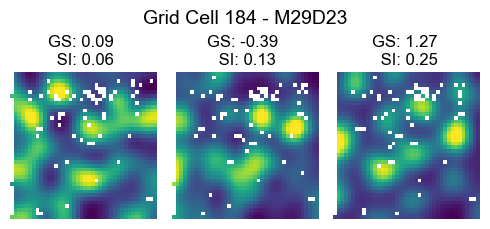

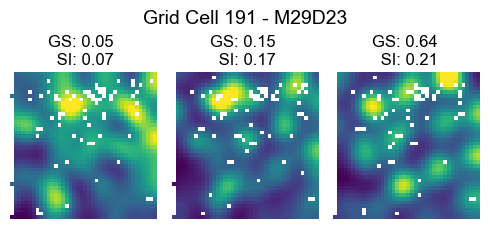

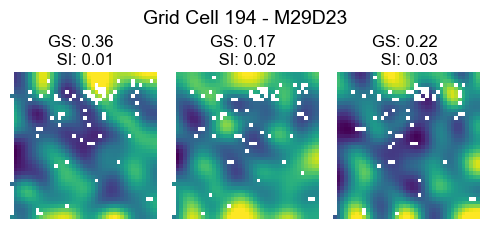

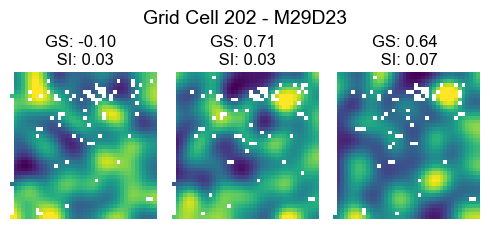

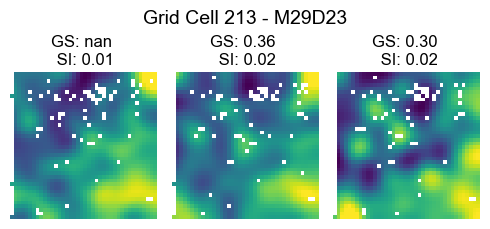

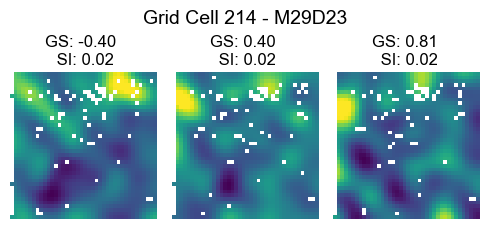

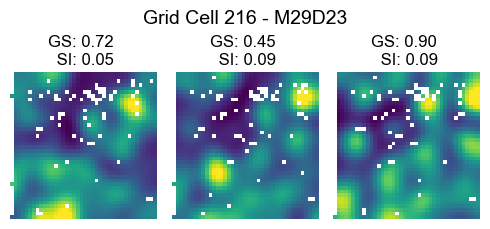

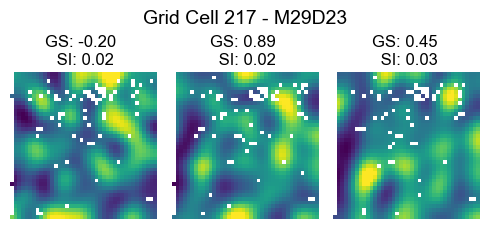

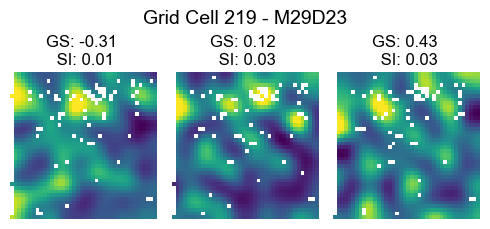

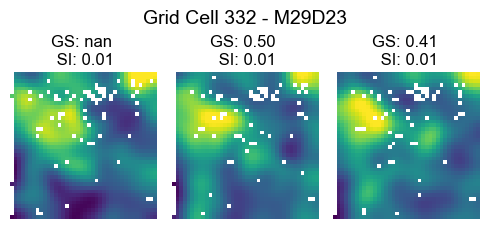

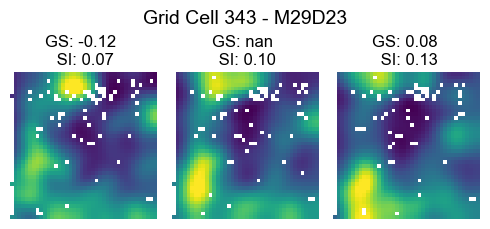

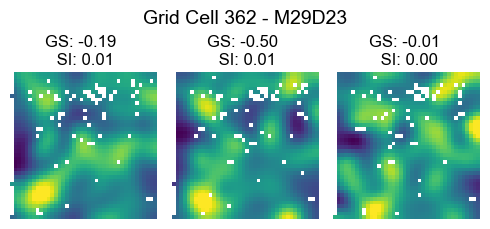

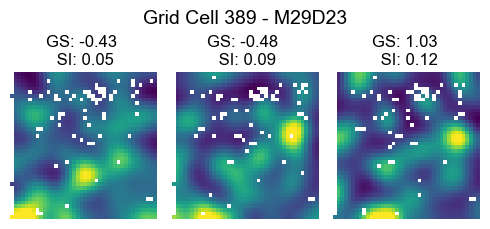

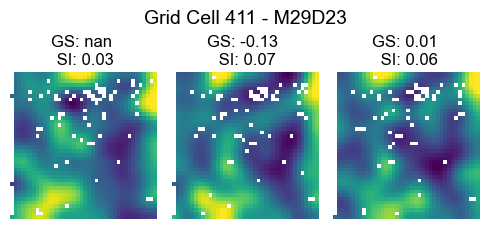

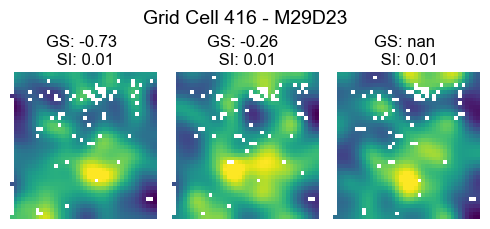

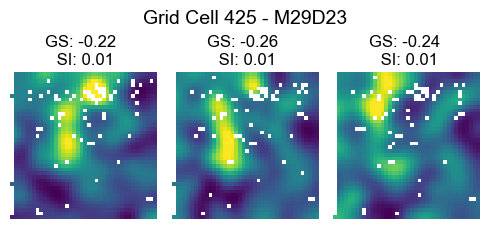

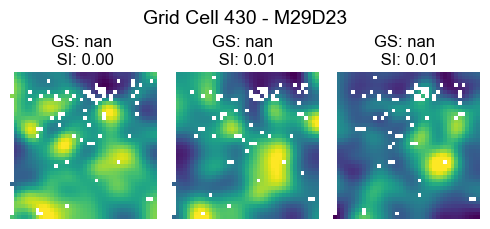

Plotting non-grid spatial cells (max 20)...


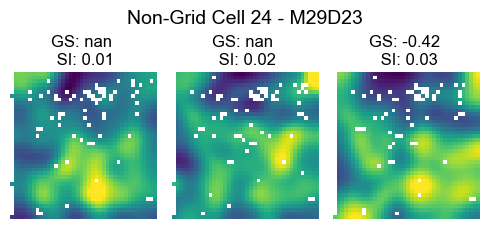

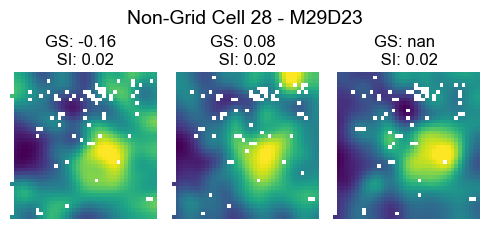

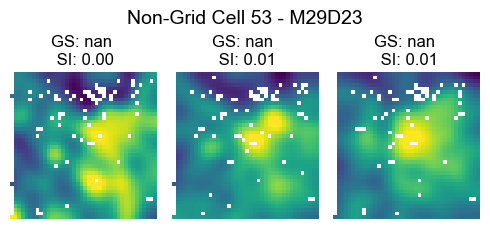

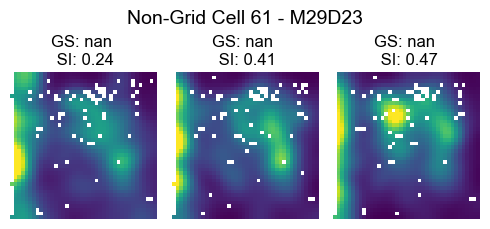

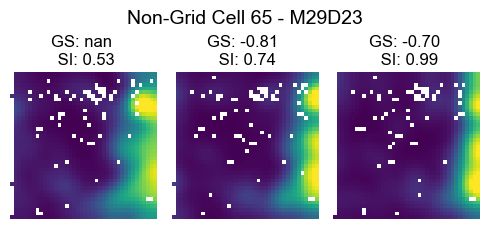

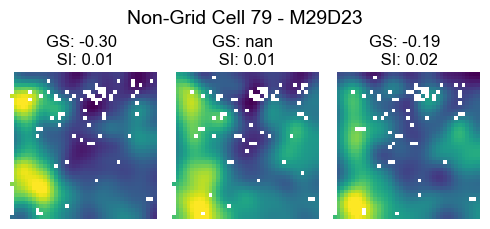

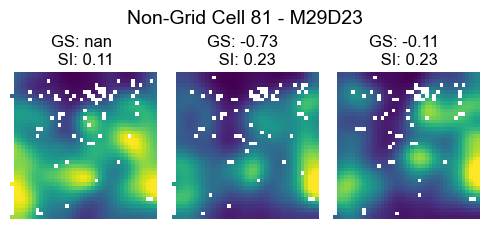

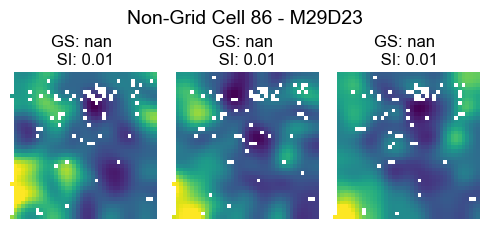

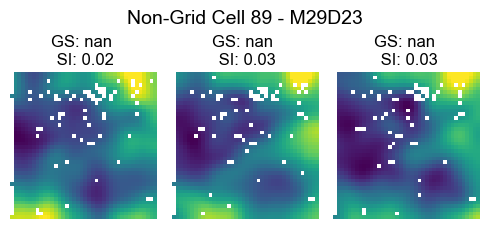

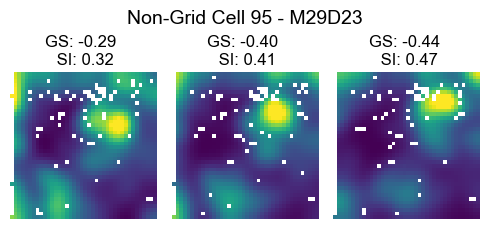

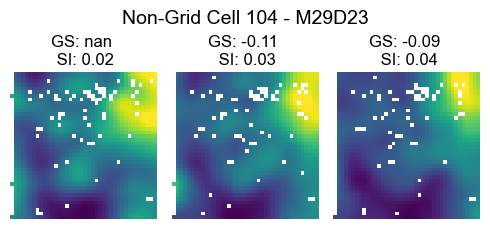

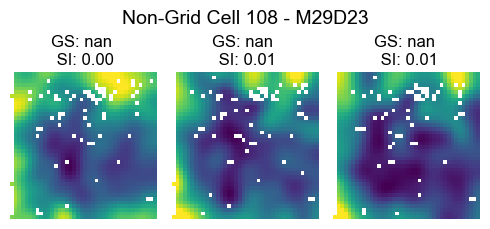

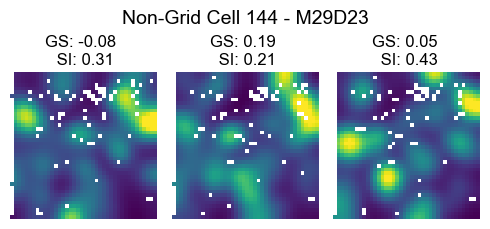

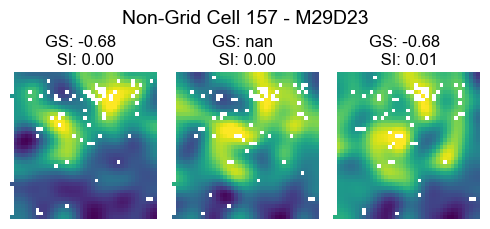

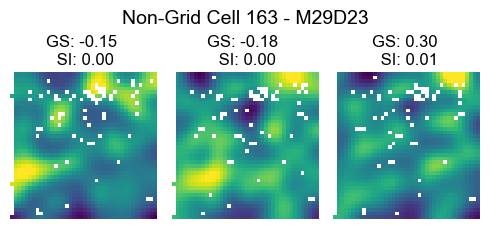

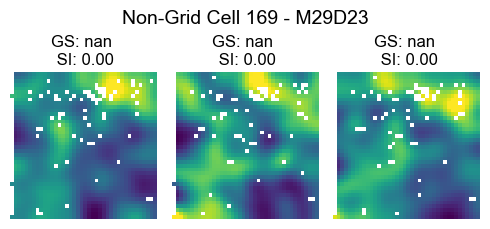

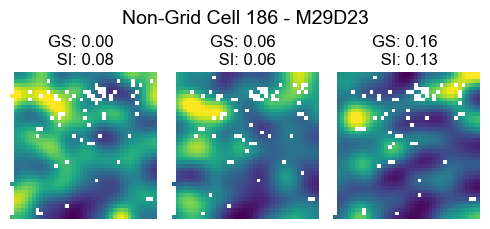

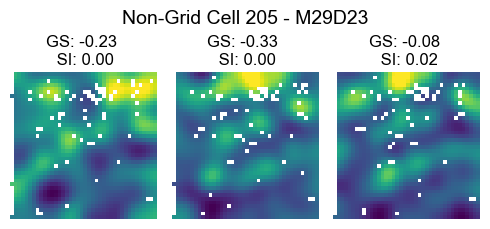

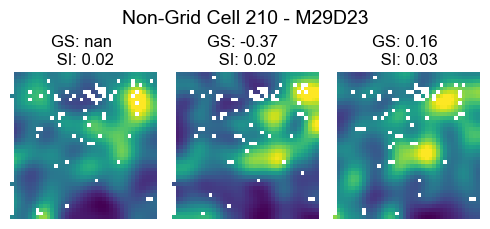

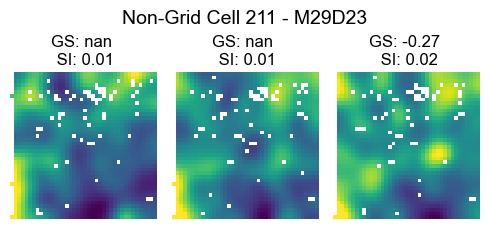

In [85]:
# Set output path for the figures
output_figpath = '/Users/harryclark/Desktop/temp/rate_maps_with_shifts/'

# Create output directory if it doesn't exist
import os
os.makedirs(output_figpath, exist_ok=True)

# Plot rate maps with shifts for all grid and non-grid cells
# Limiting to 5 cells per type for demonstration - you can increase this number
plot_all_cells_with_shifts(gcs, ngs, mouse, day, figpath=output_figpath, 
                          source_path='/Users/harryclark/Downloads/COHORT12/', 
                          max_cells_per_type=20)